## Set up

In [1]:
#importing packages
#packages for directory and file handling
import os
import glob
import json

#packages for time handling
import time as pytime
from sqlite3 import Date
import datetime

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pprint
import re
from datetime import date
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import Polynomial
from pandas.api.types import CategoricalDtype

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 


#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
files = glob.glob('fcs_files/*fcs')
sorted_files = sorted(files)
sorted_files[:5]

#import all files in the dictionary and save as new dictionary
imported_files = {}
for filename in sorted_files:
    fcs_data = FlowCal.io.FCSData(filename)
    imported_files[filename] = fcs_data

#check the shape of the imported files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(keys_shapes[:5])

[   'fcs_files/RC17 d16 rVM_ALCAM 1,3a,100 rVM_016.fcs: (11204, 11)',
    'fcs_files/RC17 d16 rVM_APCDD1 1,3a,100 rVM_017.fcs: (10115, 11)',
    'fcs_files/RC17 d16 rVM_CNTN2 1,3a,20 rVM_013.fcs: (7217, 11)',
    'fcs_files/RC17 d16 rVM_CORIN 1,3a,200 rVM_015.fcs: (7887, 11)',
    'fcs_files/RC17 d16 rVM_FOLR1 CF568 1,3a,200 rVM_018.fcs: (10891, 11)']


## Plot data

Plot as histogram

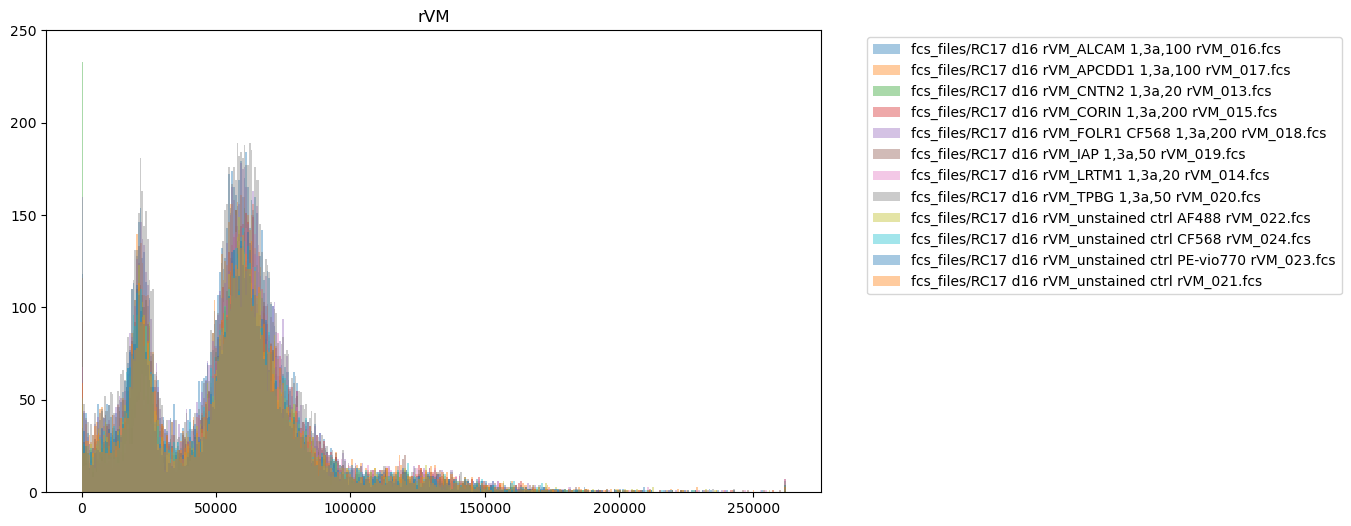

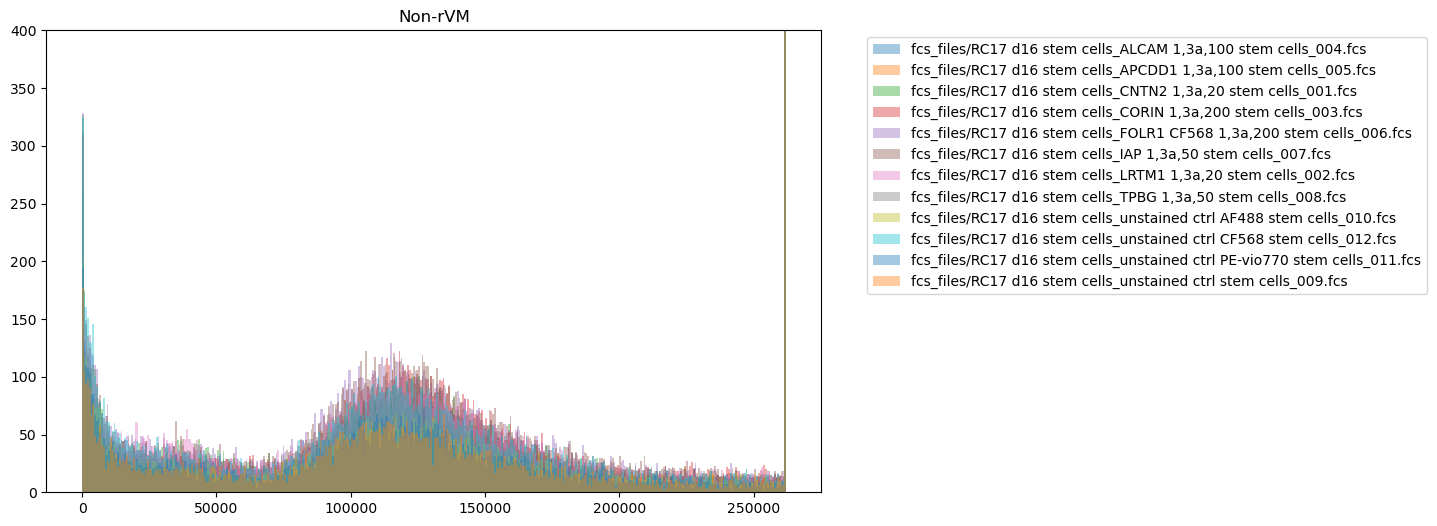

In [4]:
#define the string to filter filenames
filter_string = "rVM"

#rVM files
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    if filter_string in filename:
        folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
        plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                 label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 250)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(filter_string)
plt.show()

#stem cells files
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    if filter_string not in filename:
        folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
        plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                 label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 400)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f'Non-{filter_string}')
plt.show()

## Plot to define gating strategy

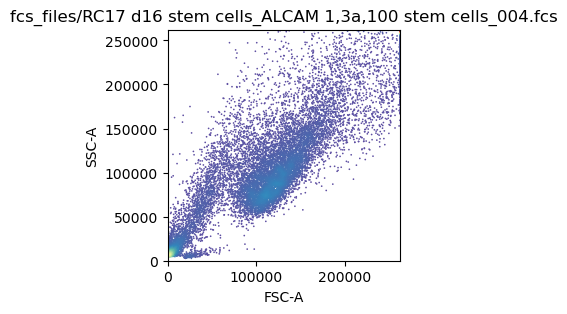

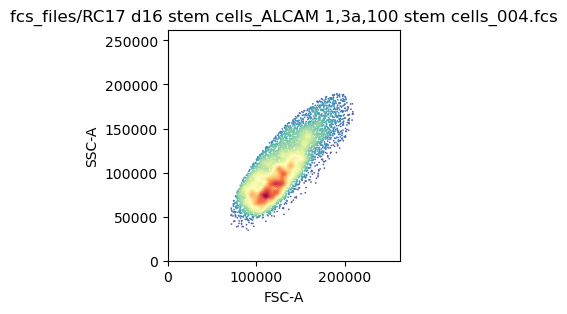

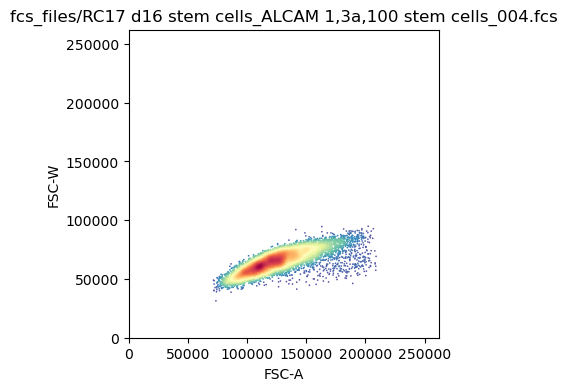

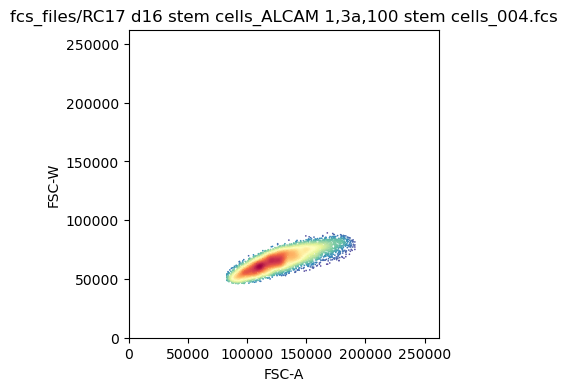

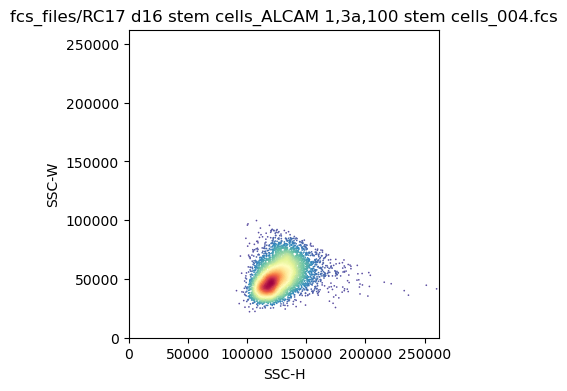

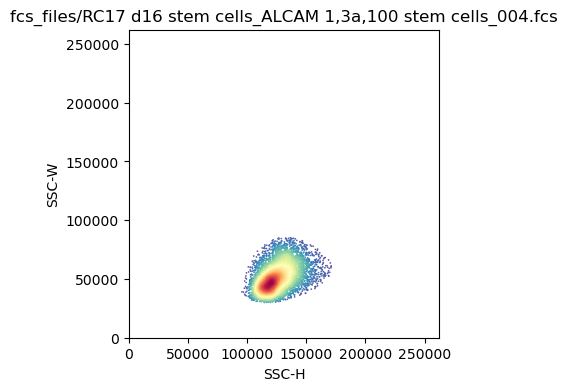

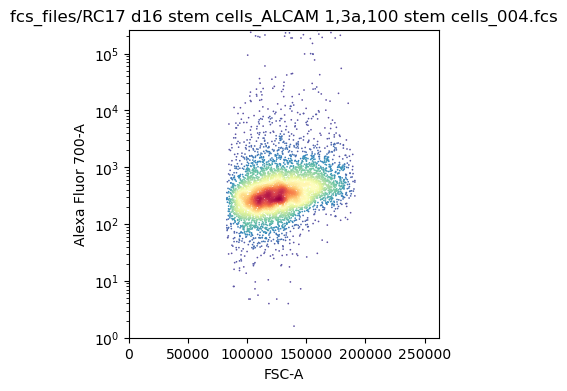

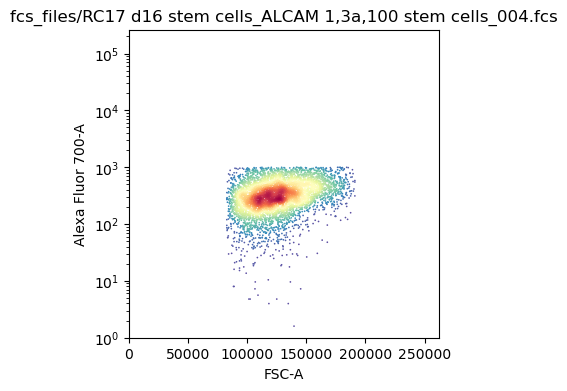

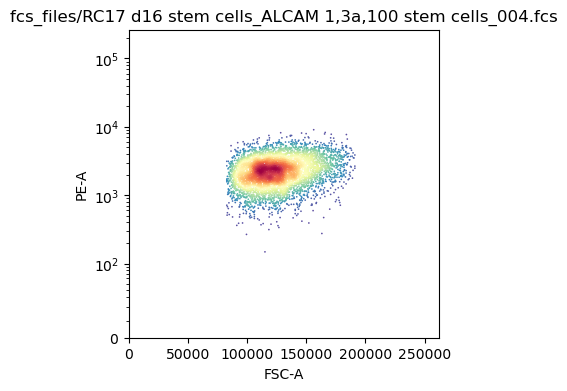

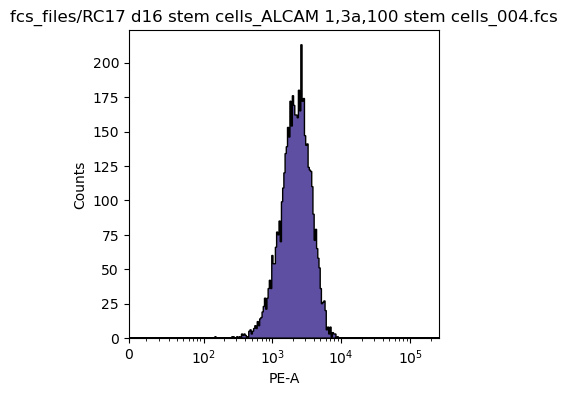

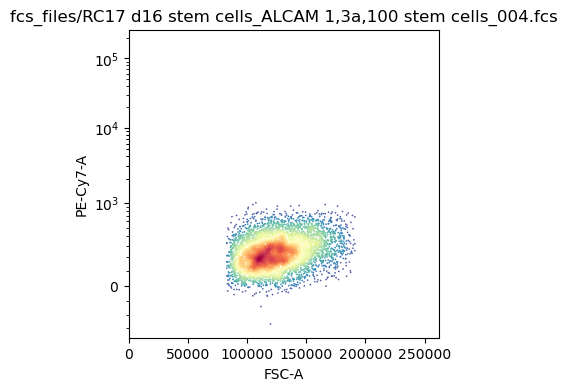

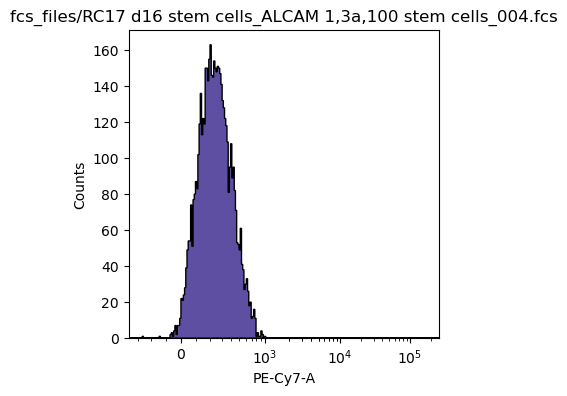

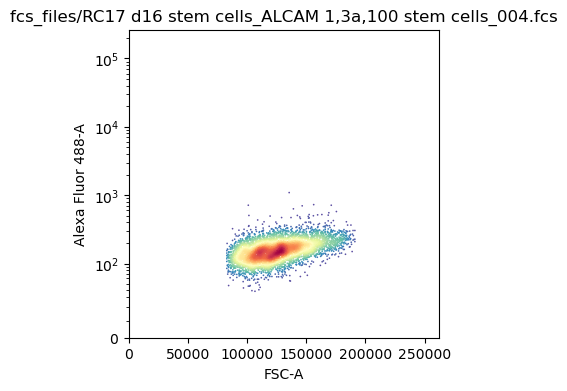

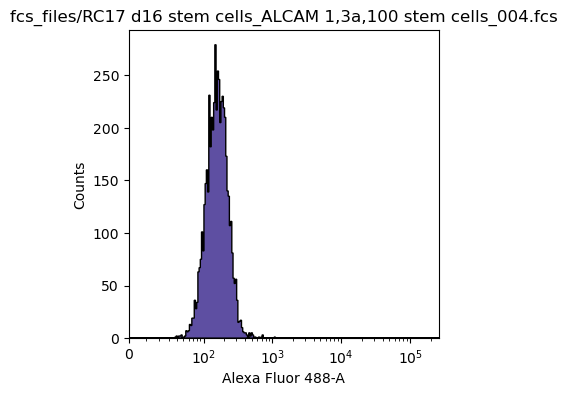

Number of events in gated sample: 5334


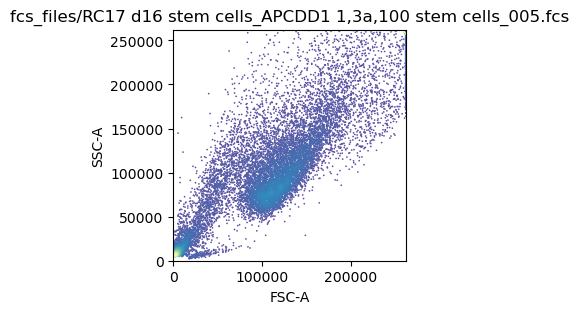

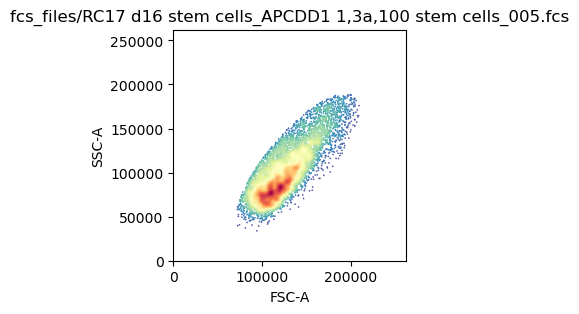

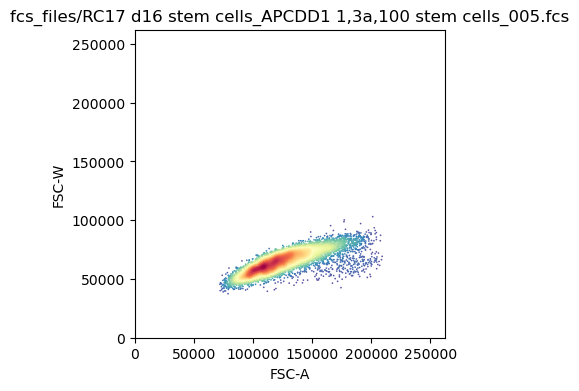

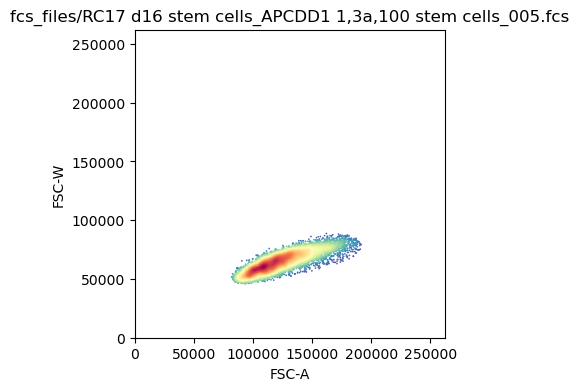

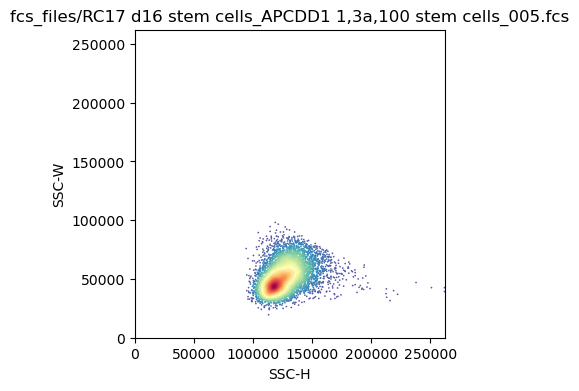

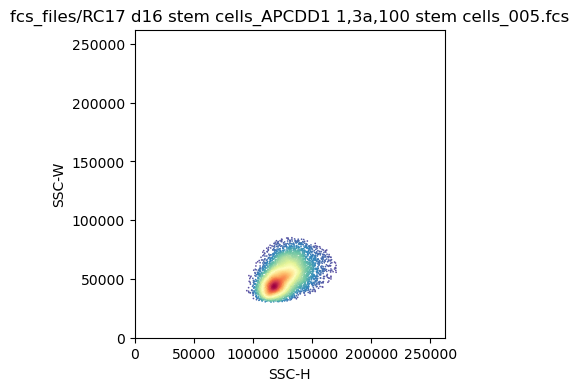

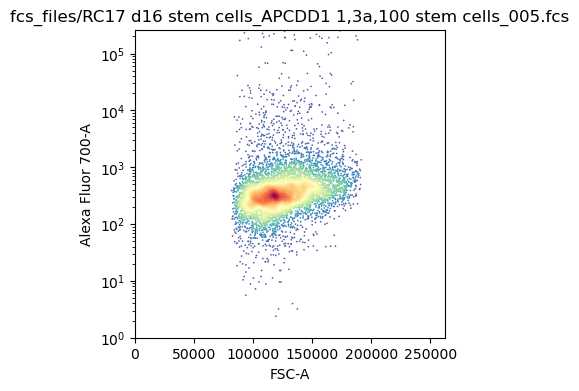

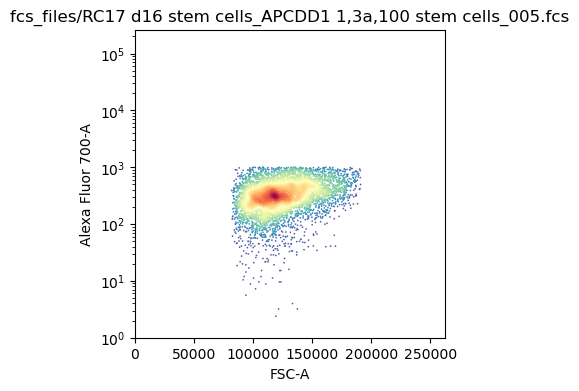

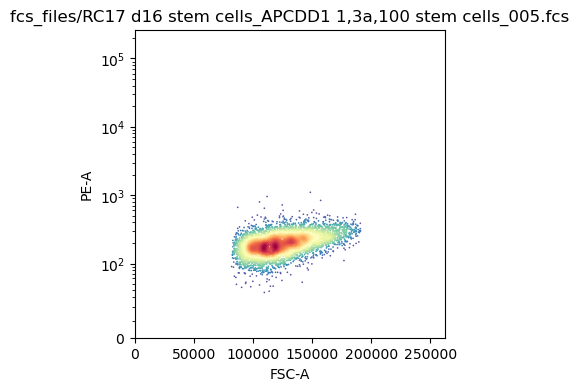

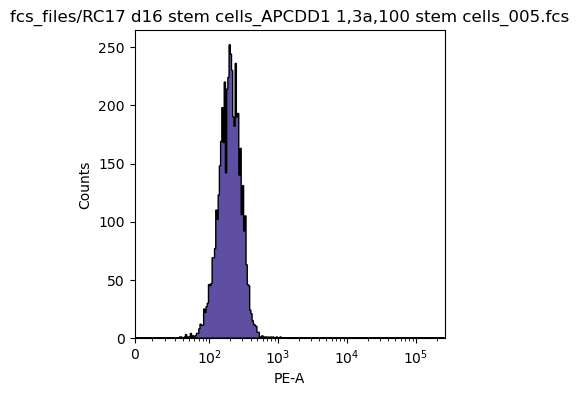

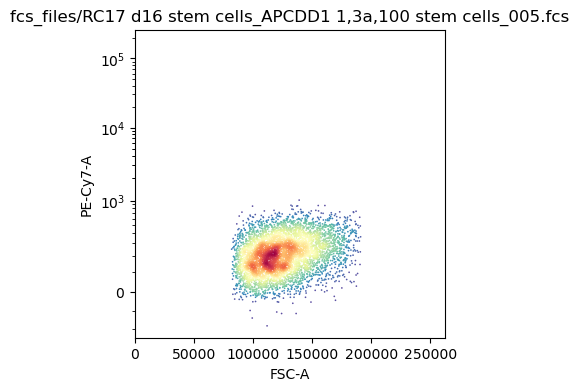

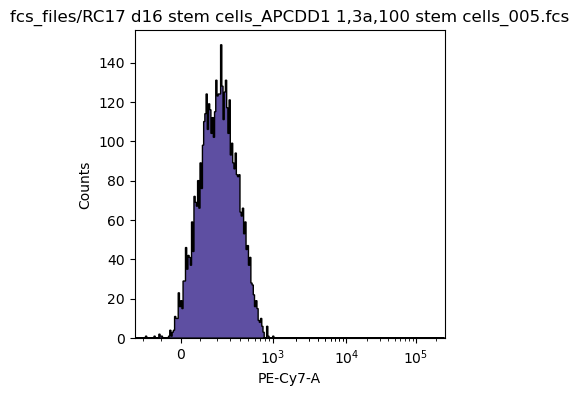

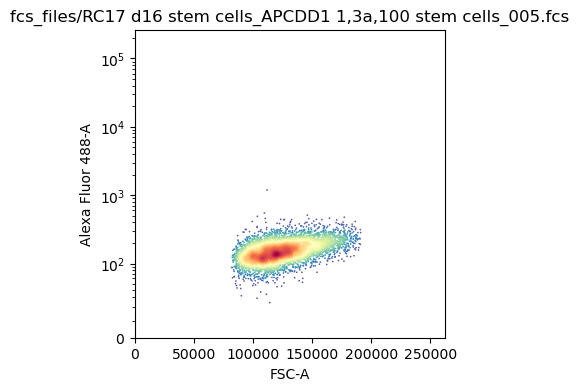

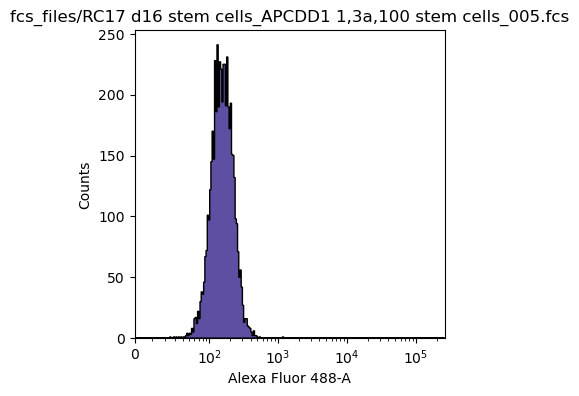

Number of events in gated sample: 5066


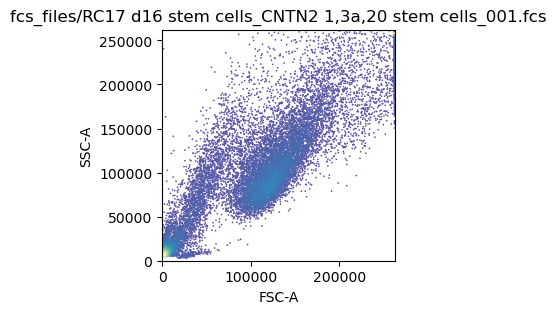

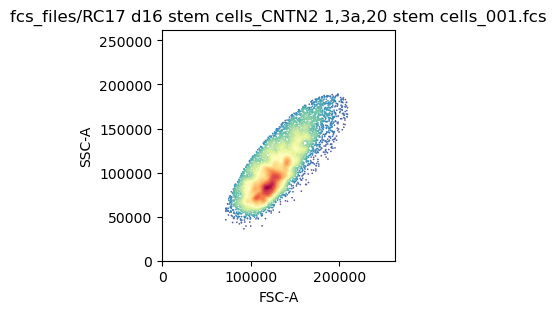

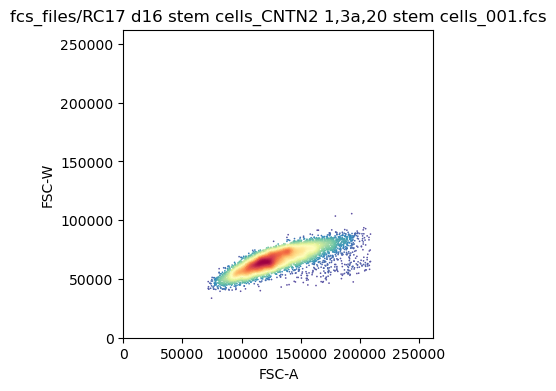

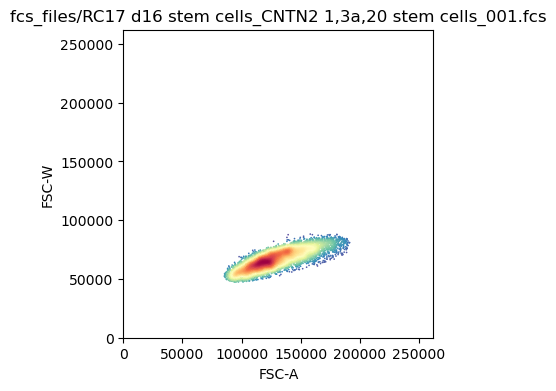

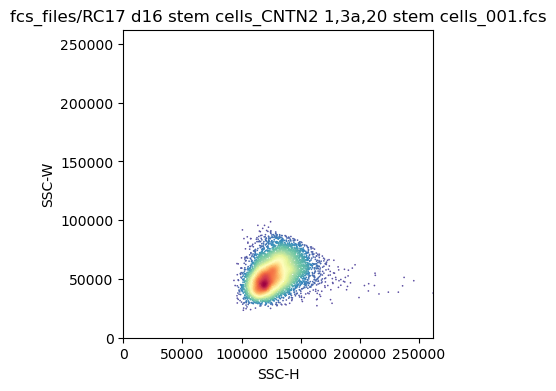

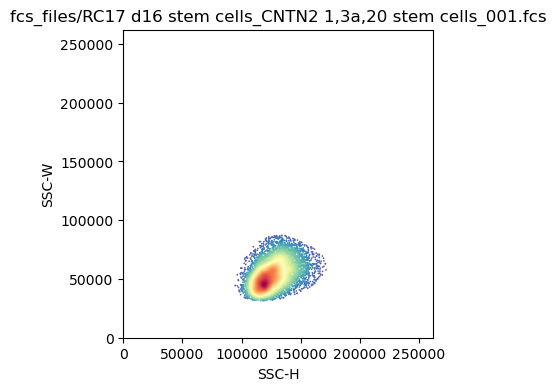

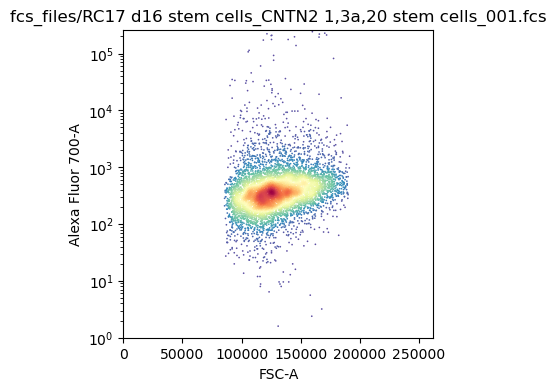

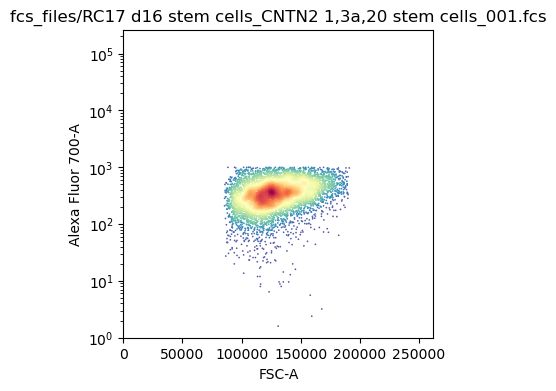

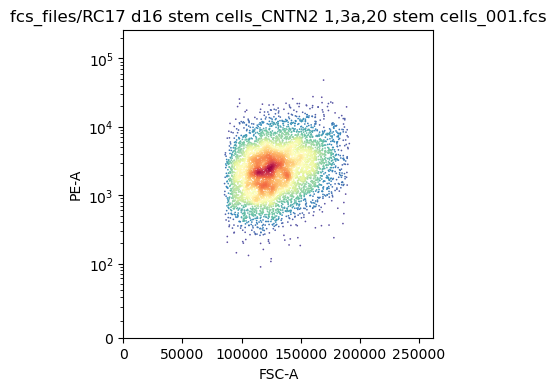

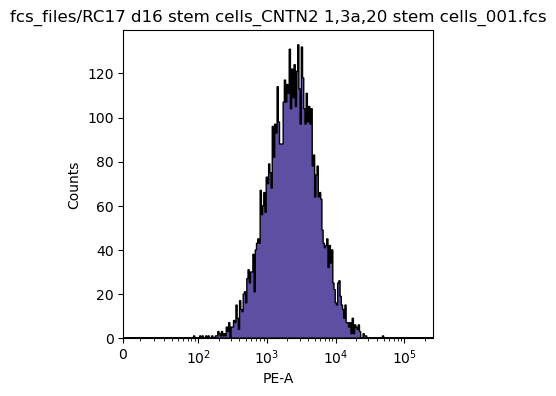

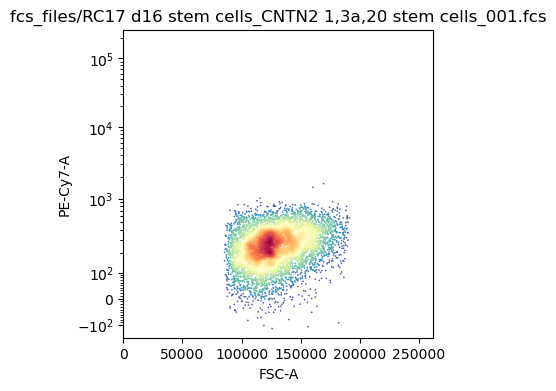

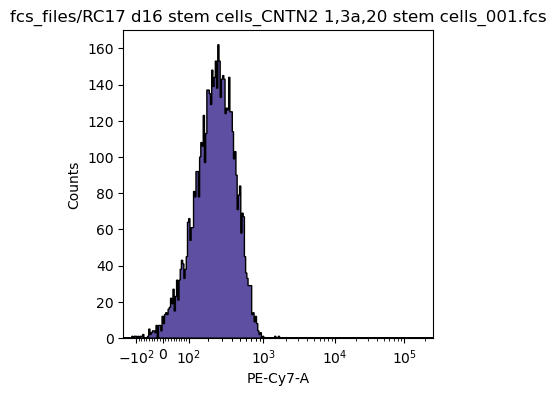

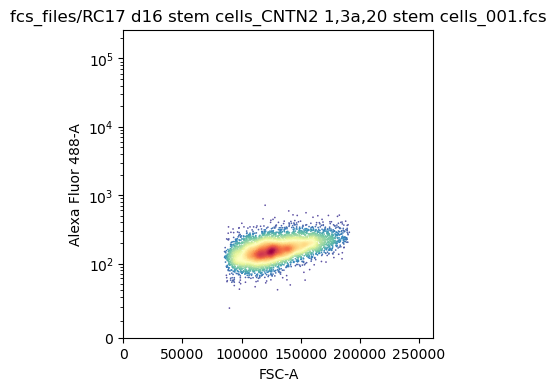

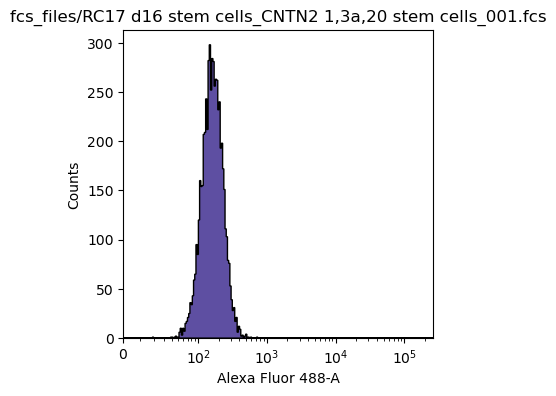

Number of events in gated sample: 5964


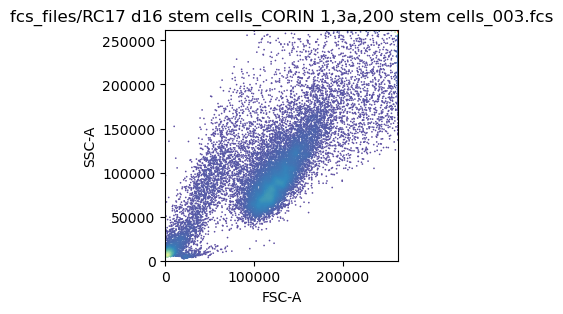

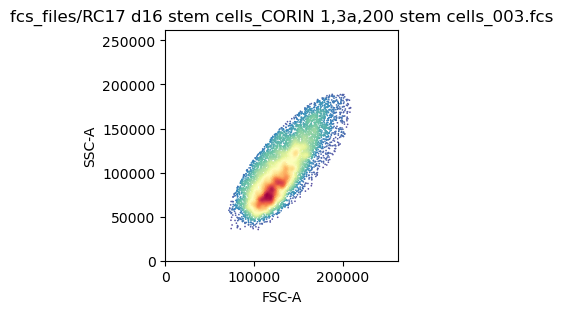

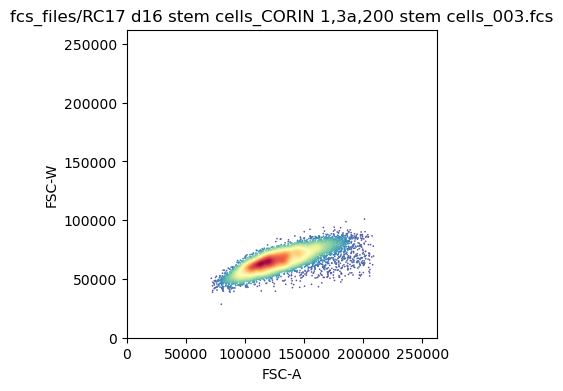

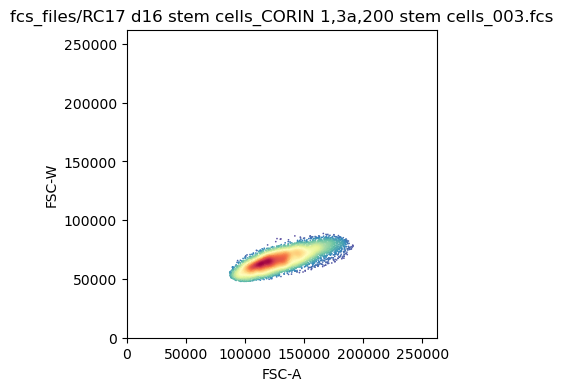

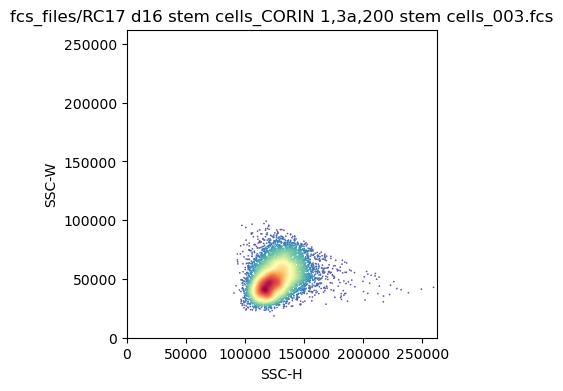

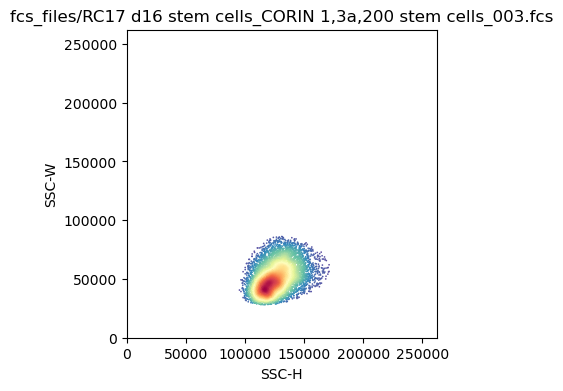

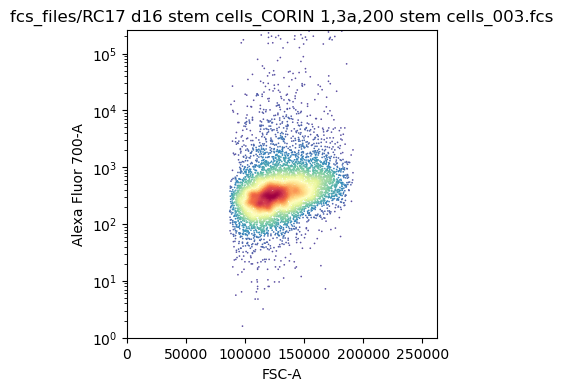

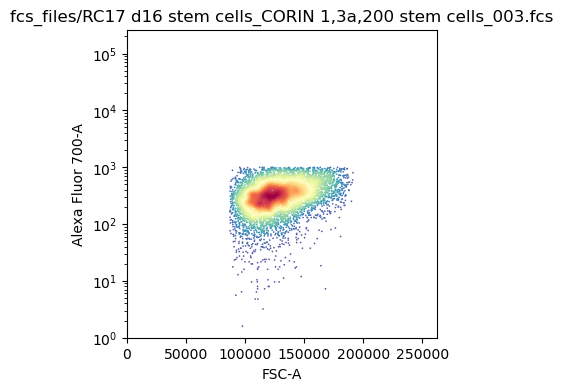

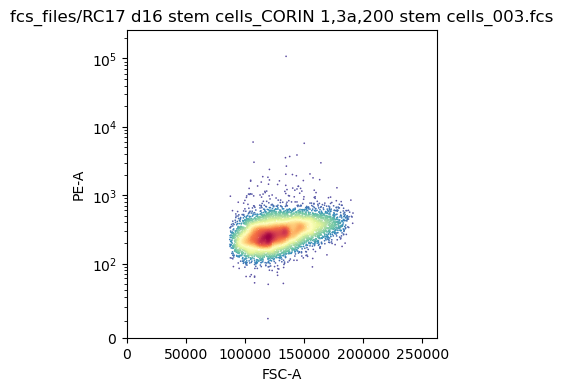

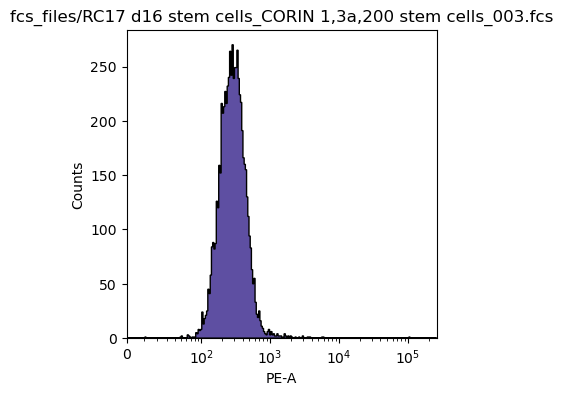

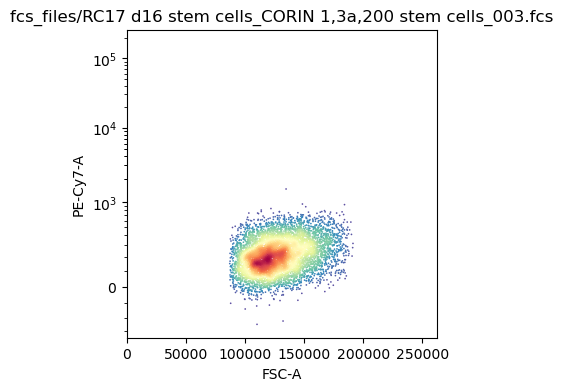

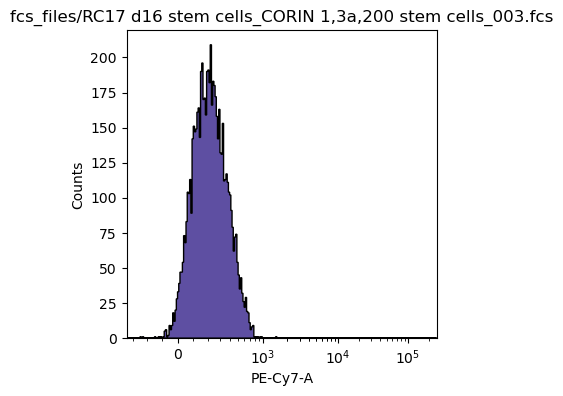

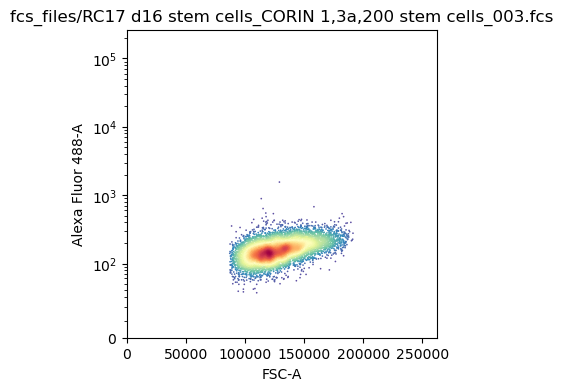

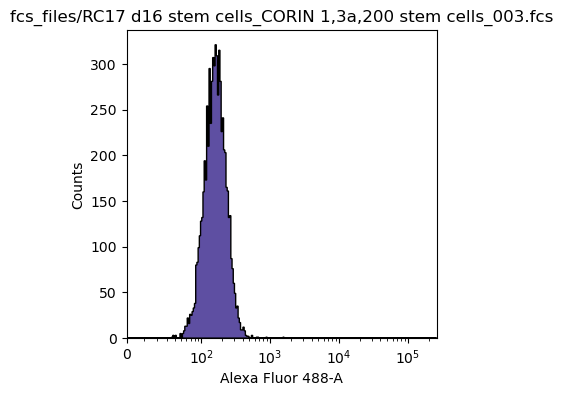

Number of events in gated sample: 6672


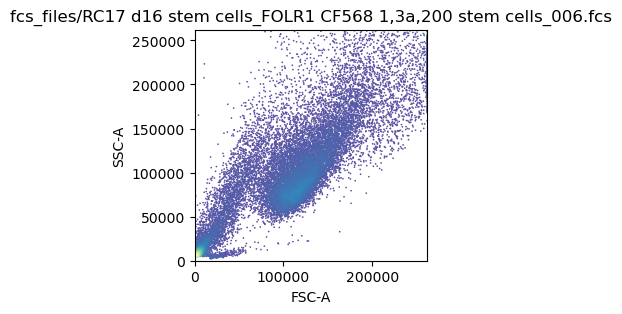

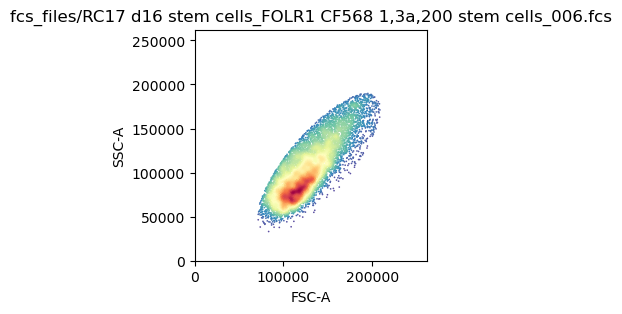

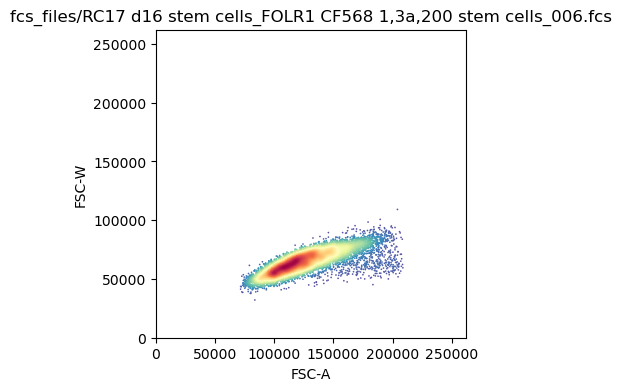

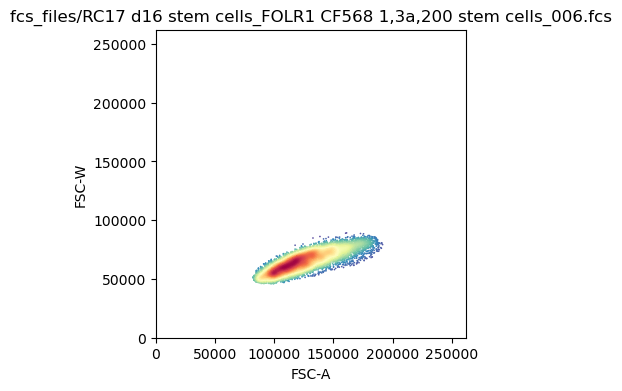

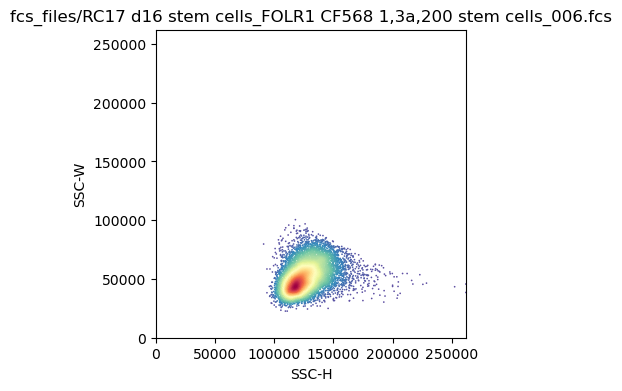

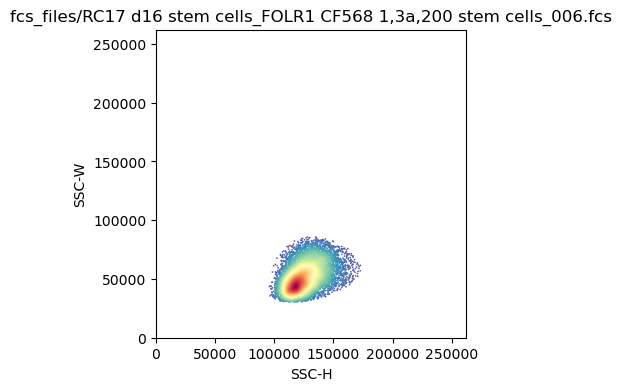

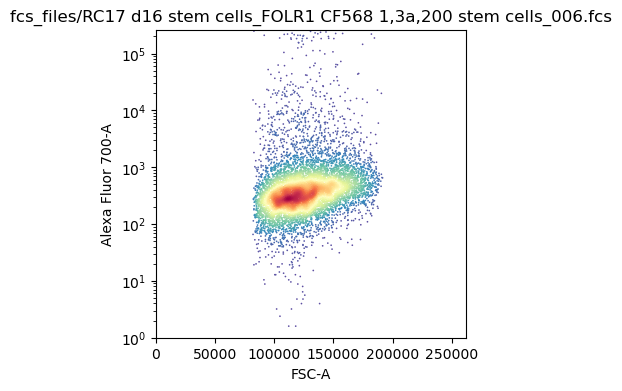

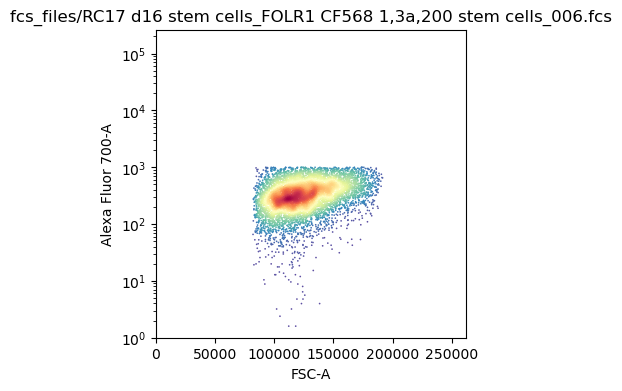

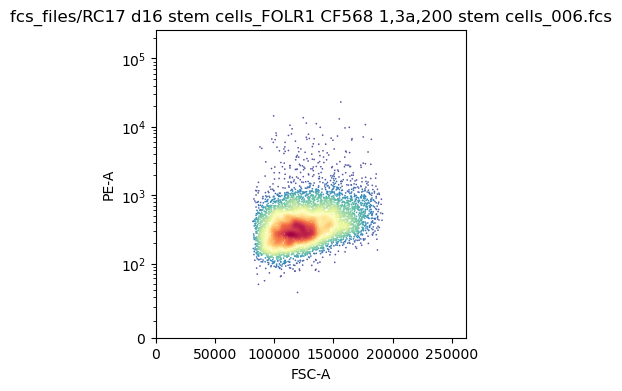

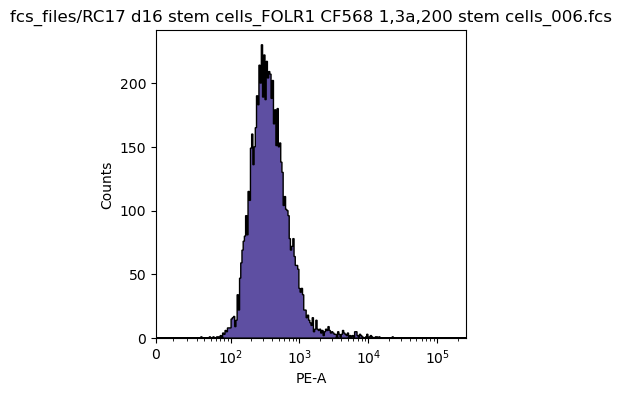

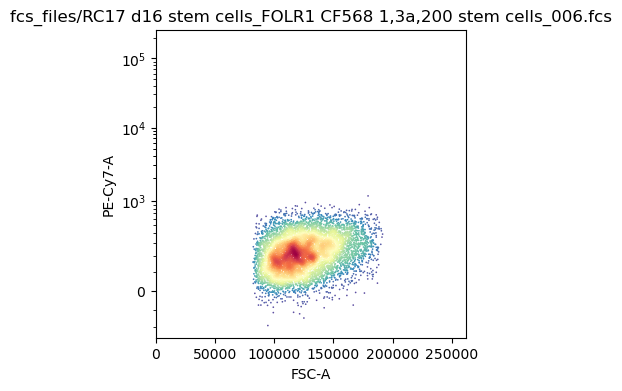

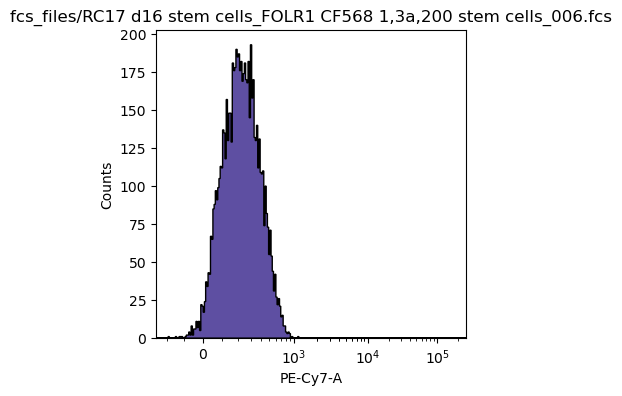

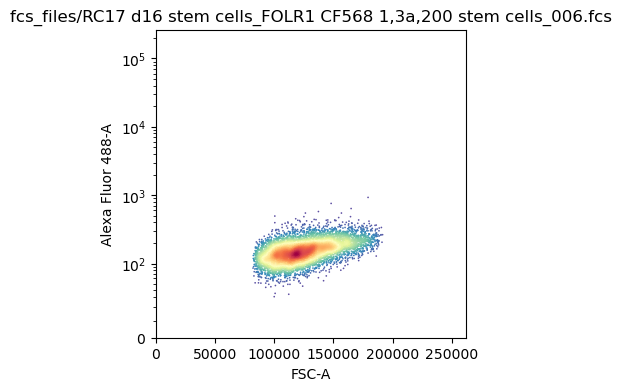

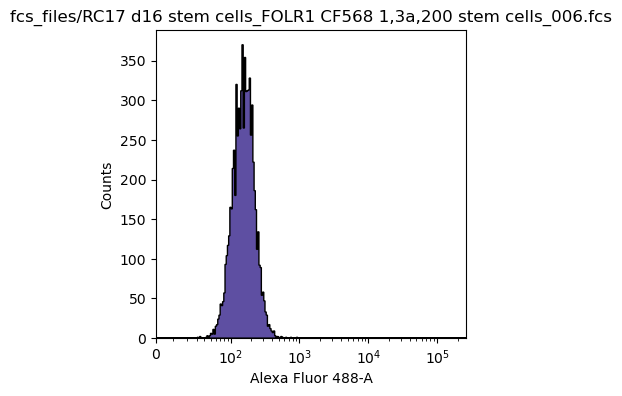

Number of events in gated sample: 7256


In [4]:
#plot with FlowCal.plot.density2d
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    #if 'rVM' not in filename:
        #continue
    if 'stem cells' not in filename:
        continue
    count += 1
    if count > 5:
        break
    
    #plot the fsc-a vs ssc-a
    plt.figure(figsize=(3, 3)) # make the figure wider
    FlowCal.plot.density2d(file, channels=['FSC-A', 'SSC-A'], mode='scatter', yscale = 'linear', xscale='linear')
    plt.title(filename)
    plt.show()

    #gate the data
    s = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                            center=(1.4e5, 1.1e5), #center (xy coordinates)
                            a=35000, #width
                            b=100000, #height
                            theta=-40/180.*np.pi #rotation
                            
                            #previous gate 
                            #center=(7e4, 4e4), #center (xy coordinates)
                            #a=25000, #width
                            #b=60000, #height
                            #theta=-40/180.*np.pi #rotation
                            #previous values: center=(6.7e4, 8e4), a=20000, b=75000, theta=-25/180.*np.pi
                            )
    
    #plot the cell gate
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(s, channels=['FSC-A','SSC-A'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in fsc-a/fsc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #3.(density) fsc-a gate
    s = FlowCal.gate.density2d(s, channels=['FSC-A','FSC-W'], gate_fraction=0.92)


    #plot the singlets-fsc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in ssc-h/ssc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #4. (density) singlets-ssc gate
    s = FlowCal.gate.density2d(s, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
    
    #plot the singlets-ssc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in draq7
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()

     #5. (threshhold) live gate
    s = FlowCal.gate.high_low(s, channels=['Alexa Fluor 700-A'], high=1000)

    #plot the data 
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #6. gating in markers of interest    
    #6.1 pe
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','PE-A'],  mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #plot the data as histogram
    plt.figure(figsize=(4, 4))
    FlowCal.plot.hist1d(s, channel='PE-A')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    #6.2 pe-cy7
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','PE-Cy7-A'], mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #plot the data as histogram
    plt.figure(figsize=(4, 4))
    FlowCal.plot.hist1d(s, channel='PE-Cy7-A')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #6.3 af488
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 488-A'],  mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #plot the data as histogram
    plt.figure(figsize=(4, 4))
    FlowCal.plot.hist1d(s, channel='Alexa Fluor 488-A')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    print(f"Number of events in gated sample: {s.shape[0]}")

## Create cut-off dictionary

In [5]:
# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {'PE-Cy7': [], 'AF488': [], 'PE': []}

#mean and standard deviation
fmo_means = {'PE-Cy7': [], 'AF488': [], 'PE': []}
fmo_stds = {'PE-Cy7': [], 'AF488': [], 'PE': []}

for i, (filename, file) in enumerate(imported_files.items()):
    if 'unstained ctrl' in filename:
        #only include samples with 'stem cells' in the filename
        if 'stem cells' not in filename:
            continue
        
        #gate the cells
        g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1.4e5, 1.1e5), a=35000, b=100000, theta=-40/180.*np.pi)
        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
        g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)

        #calculate the 99.8th percentile of the fmo's
        if 'PE-vio770' in filename and 'PE-Cy7-A' in g4.channels:
            #print(f"Processing {filename} with PE-Cy7-A channel")
            fmo_percentiles['PE-Cy7'].append(np.percentile(g4[:, 'PE-Cy7-A'], 99.9))
            fmo_means['PE-Cy7'].append(np.mean(g4[:, 'PE-Cy7-A']))
            fmo_stds['PE-Cy7'].append(np.std(g4[:, 'PE-Cy7-A']))
        elif 'AF488' in filename and 'Alexa Fluor 488-A' in g4.channels:
            #print(f"Processing {filename} with Alexa Fluor 488-A channel")
            fmo_percentiles['AF488'].append(np.percentile(g4[:, 'Alexa Fluor 488-A'], 99.9))
            fmo_means['AF488'].append(np.mean(g4[:, 'Alexa Fluor 488-A']))
            fmo_stds['AF488'].append(np.std(g4[:, 'Alexa Fluor 488-A']))
        elif ('009' in filename or 'CF568' in filename) and 'PE-A' in g4.channels:
            print(f"Processing {filename} with PE-A channel")
            fmo_percentiles['PE'].append(np.percentile(g4[:, 'PE-A'], 99.9))
            fmo_means['PE'].append(np.mean(g4[:, 'PE-A']))
            fmo_stds['PE'].append(np.std(g4[:, 'PE-A']))

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {k: np.mean(v) for k, v in fmo_percentiles.items()}
mean_of_means = {k: np.mean(v) for k, v in fmo_means.items()}
mean_of_stds = {k: np.mean(v) for k, v in fmo_stds.items()}
std_cutoffs_3 = {k: mean + 3*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())} #3 sd
std_cutoffs_8 = {k: mean + 8*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())} #3 sd

print(f"99.8th %:\n{perc_cutoffs}")
print(f"mean+3sd:\n{std_cutoffs_3}")
print(f"mean+8sd:\n{std_cutoffs_8}")

Processing fcs_files/RC17 d16 stem cells_unstained ctrl CF568 stem cells_012.fcs with PE-A channel
Processing fcs_files/RC17 d16 stem cells_unstained ctrl stem cells_009.fcs with PE-A channel
99.8th %:
{'PE-Cy7': 931.6611748047081, 'AF488': 452.1684297180231, 'PE': 503.36034820556733}
mean+3sd:
{'PE-Cy7': 680.0802917480469, 'AF488': 356.6250534057617, 'PE': 401.9550018310547}
mean+8sd:
{'PE-Cy7': 1420.2813262939453, 'AF488': 673.1221313476562, 'PE': 753.181884765625}


## Plot the data with the cut-off values

Processing... fcs_files/RC17 d16 rVM_ALCAM 1,3a,100 rVM_016.fcs
Processing... fcs_files/RC17 d16 rVM_APCDD1 1,3a,100 rVM_017.fcs
Processing... fcs_files/RC17 d16 rVM_CNTN2 1,3a,20 rVM_013.fcs
Processing... fcs_files/RC17 d16 rVM_CORIN 1,3a,200 rVM_015.fcs
Processing... fcs_files/RC17 d16 rVM_FOLR1 CF568 1,3a,200 rVM_018.fcs
Processing... fcs_files/RC17 d16 rVM_IAP 1,3a,50 rVM_019.fcs
Processing... fcs_files/RC17 d16 rVM_LRTM1 1,3a,20 rVM_014.fcs
Processing... fcs_files/RC17 d16 rVM_TPBG 1,3a,50 rVM_020.fcs
Processing... fcs_files/RC17 d16 rVM_unstained ctrl AF488 rVM_022.fcs
Processing... fcs_files/RC17 d16 rVM_unstained ctrl CF568 rVM_024.fcs
Processing... fcs_files/RC17 d16 rVM_unstained ctrl PE-vio770 rVM_023.fcs
Processing... fcs_files/RC17 d16 rVM_unstained ctrl rVM_021.fcs
Processing... fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 stem cells_004.fcs
Processing... fcs_files/RC17 d16 stem cells_APCDD1 1,3a,100 stem cells_005.fcs
Processing... fcs_files/RC17 d16 stem cells_CNTN2 1,3

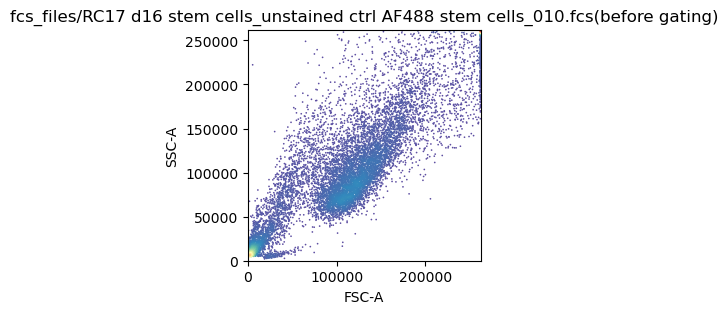

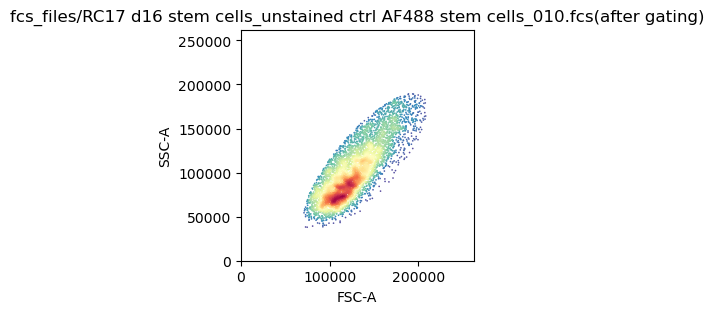

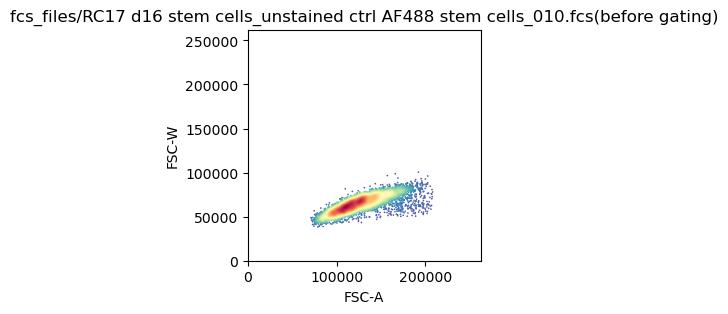

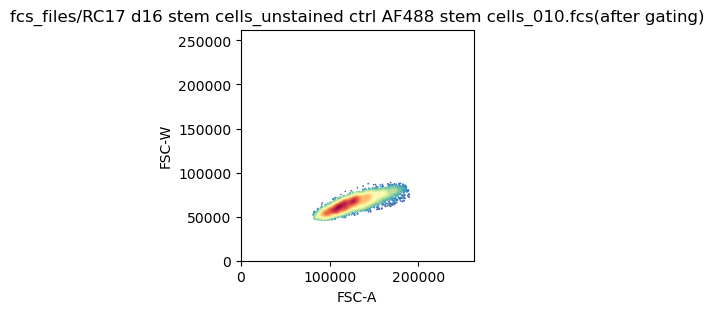

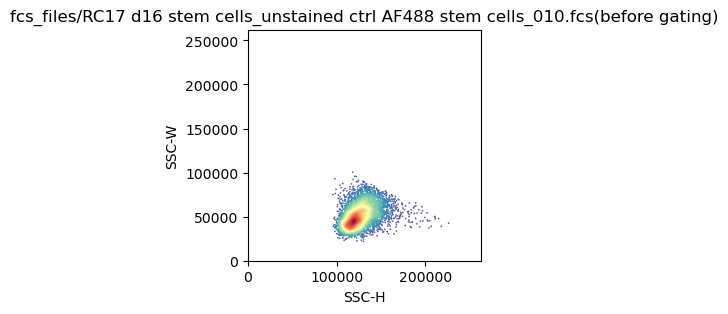

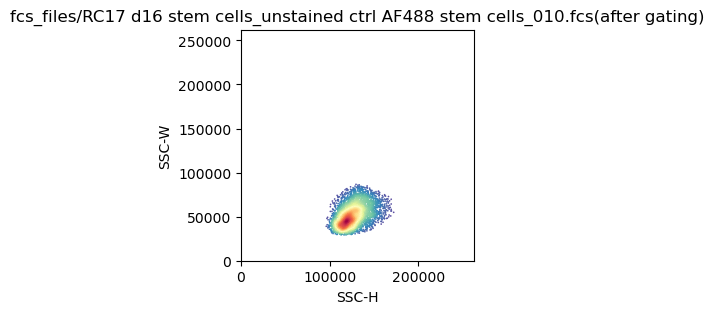

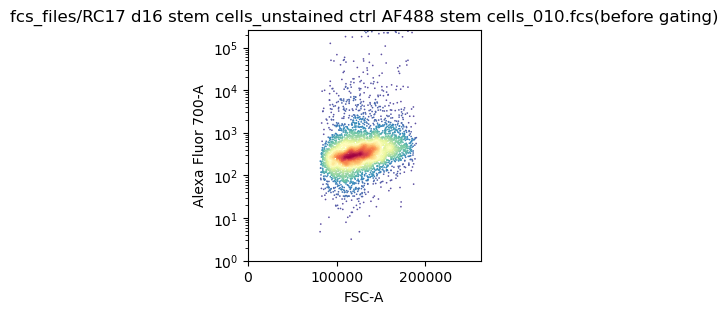

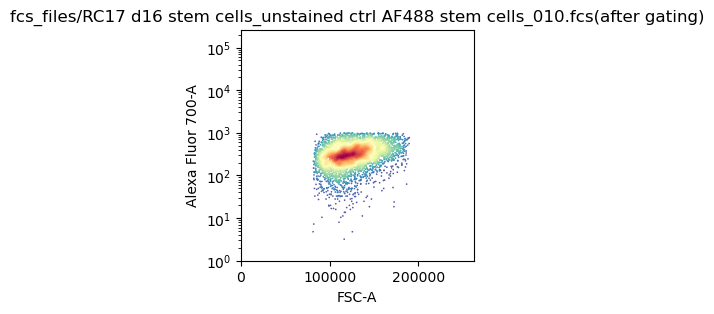

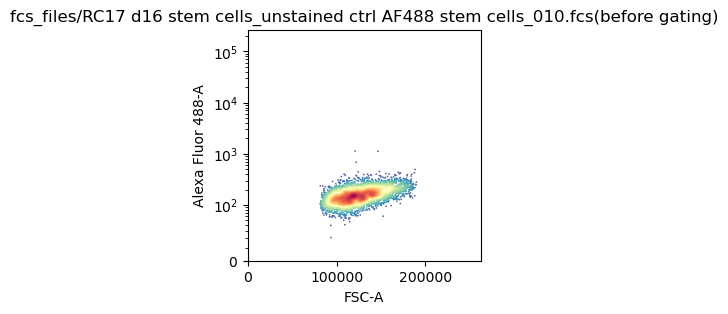

Cutoff key for Alexa Fluor 488-A: AF488, Cutoff value: 452.1684297180231


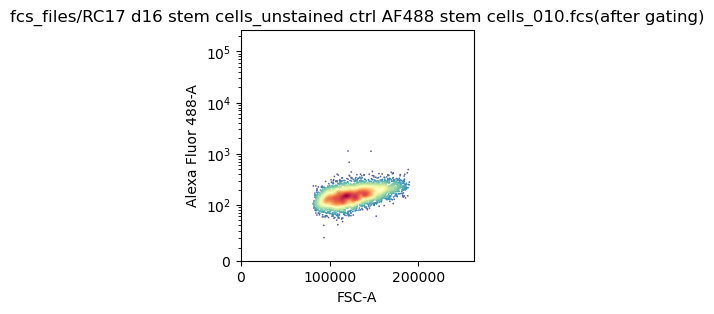

Applying gate on Alexa Fluor 488-A with cutoff 452.1684297180231 (inverse=True)
Initial count: 4122, Final count after gating: 5, Percentage retained: 0.12%


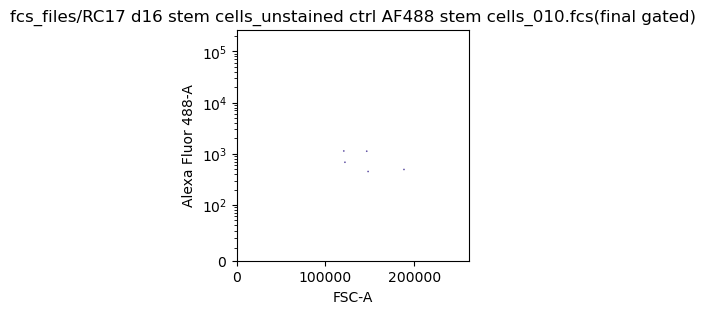

Processing... fcs_files/RC17 d16 stem cells_unstained ctrl CF568 stem cells_012.fcs


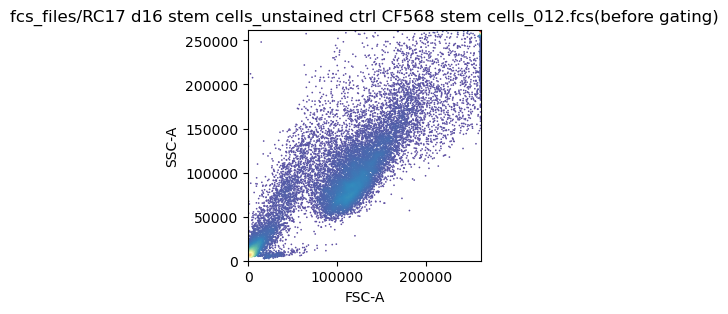

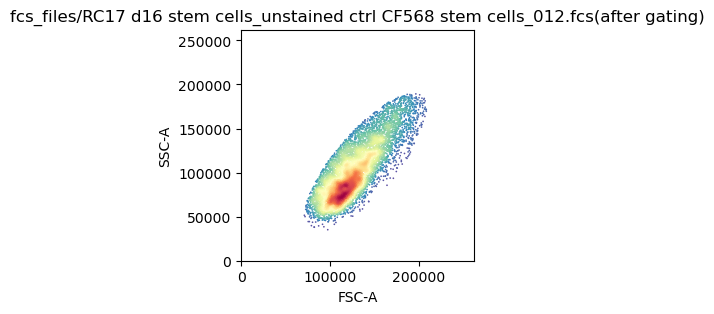

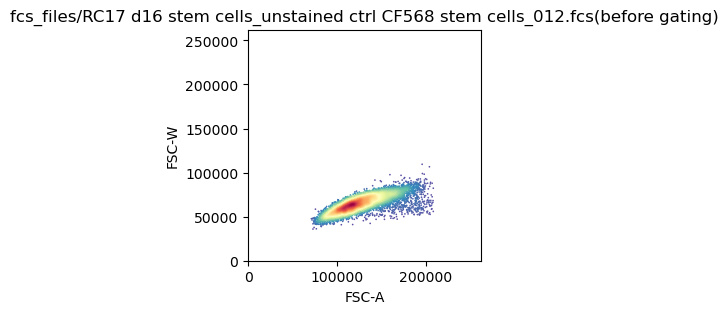

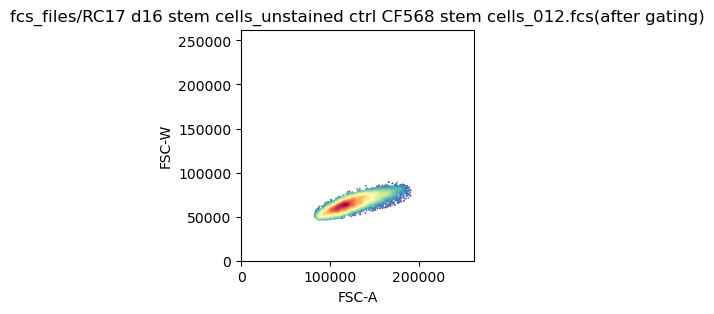

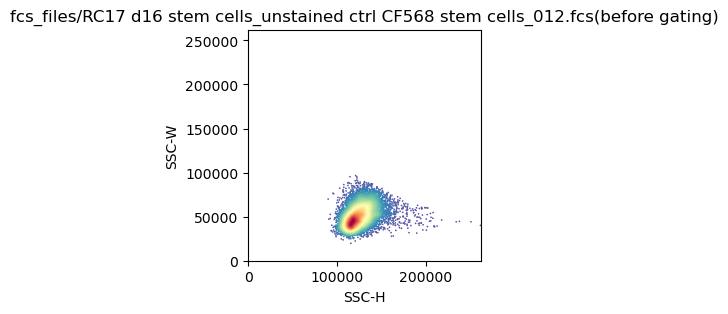

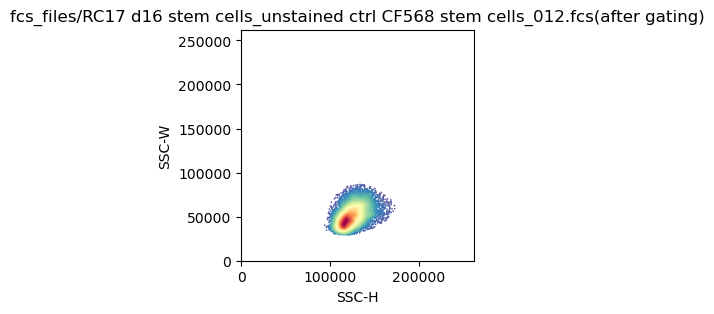

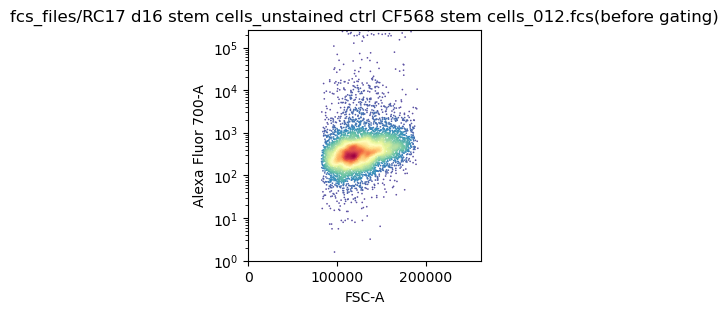

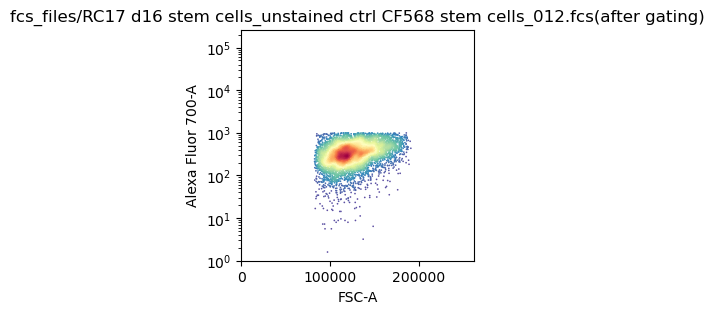

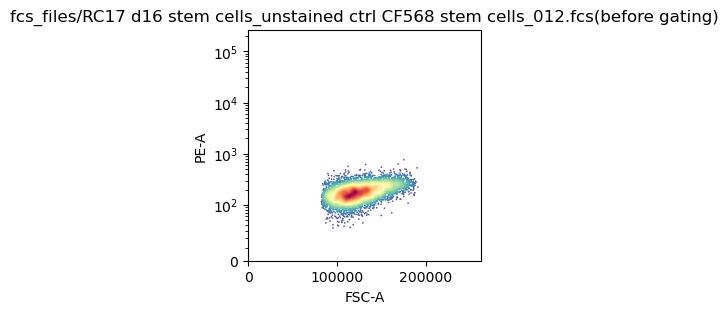

Cutoff key for PE-A: PE, Cutoff value: 503.36034820556733


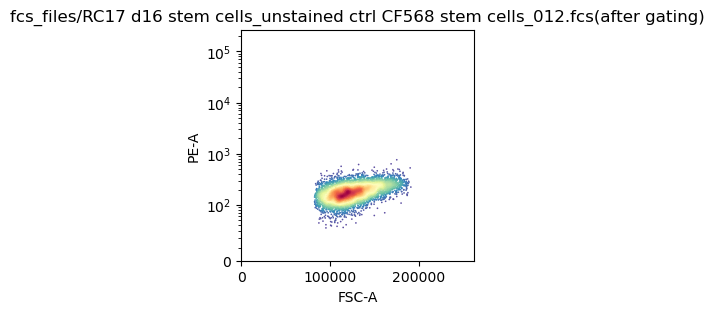

Applying gate on PE-A with cutoff 503.36034820556733 (inverse=True)
Initial count: 6148, Final count after gating: 8, Percentage retained: 0.13%


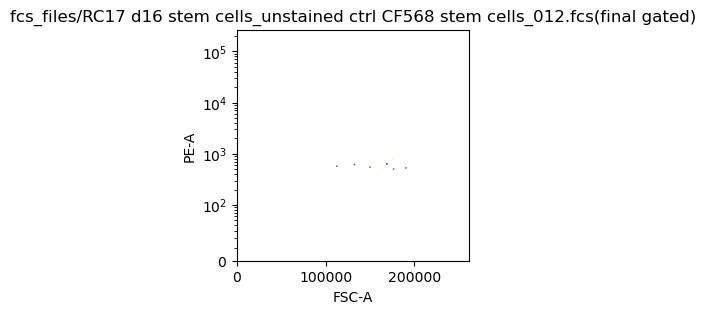

Processing... fcs_files/RC17 d16 stem cells_unstained ctrl PE-vio770 stem cells_011.fcs


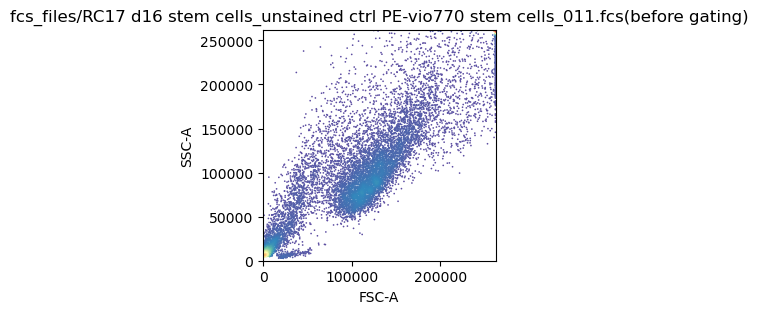

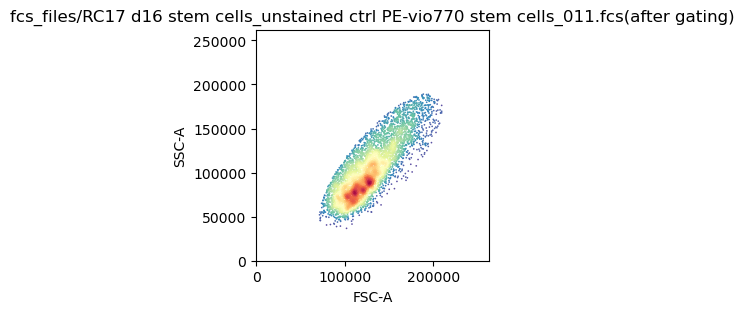

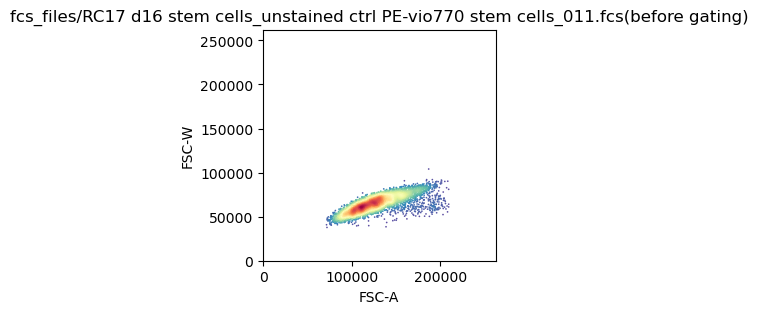

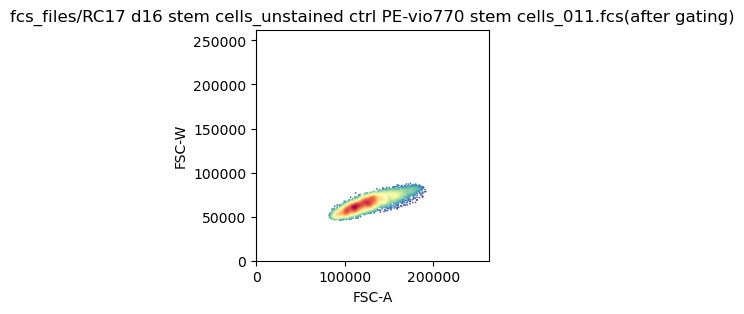

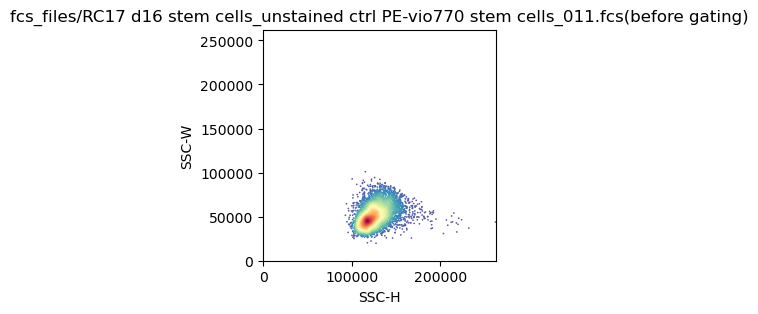

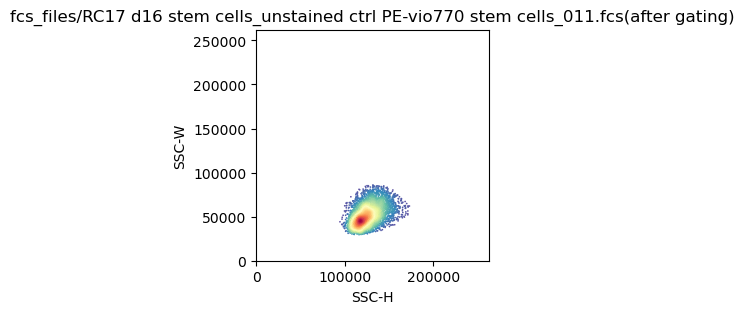

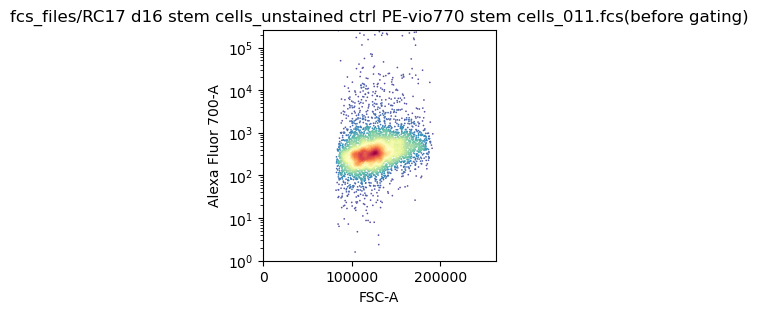

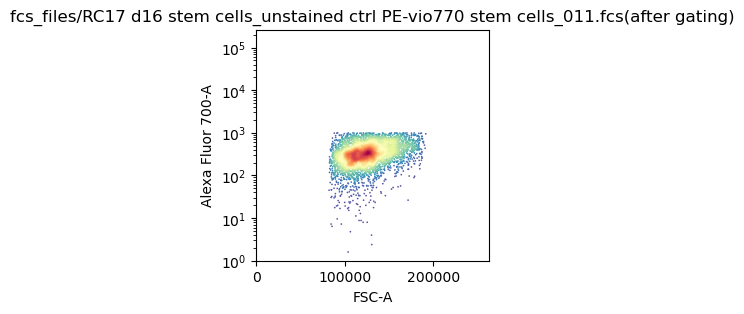

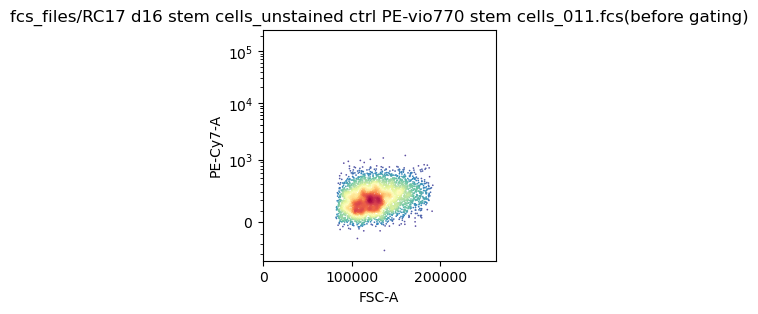

Cutoff key for PE-Cy7-A: PE-Cy7, Cutoff value: 931.6611748047081


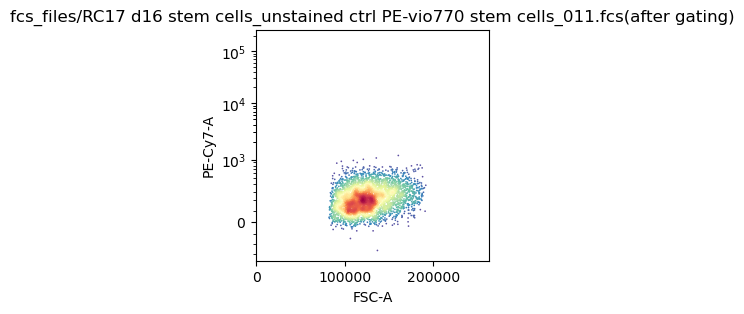

Applying gate on PE-Cy7-A with cutoff 931.6611748047081 (inverse=True)
Initial count: 4065, Final count after gating: 5, Percentage retained: 0.12%


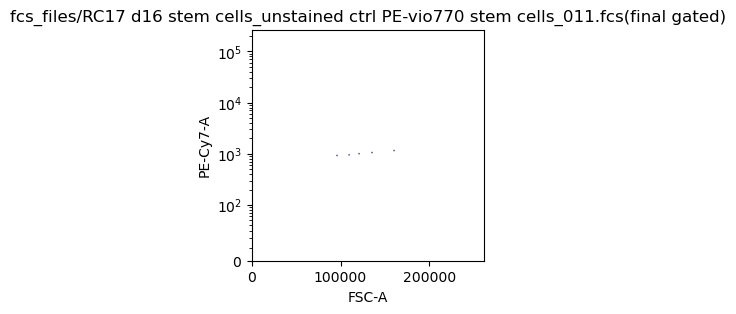

Processing... fcs_files/RC17 d16 stem cells_unstained ctrl stem cells_009.fcs


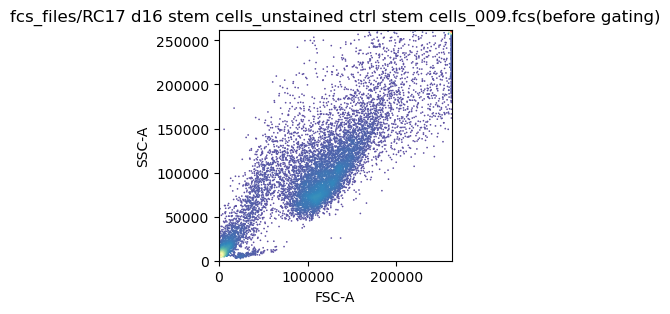

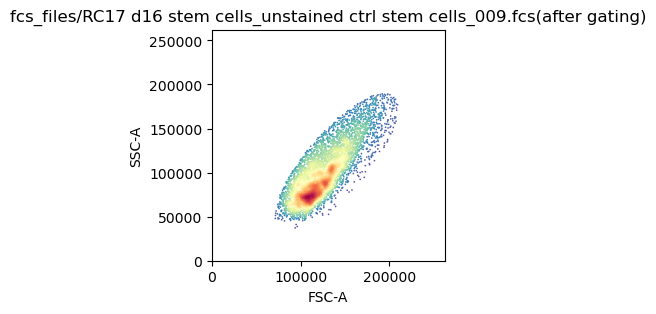

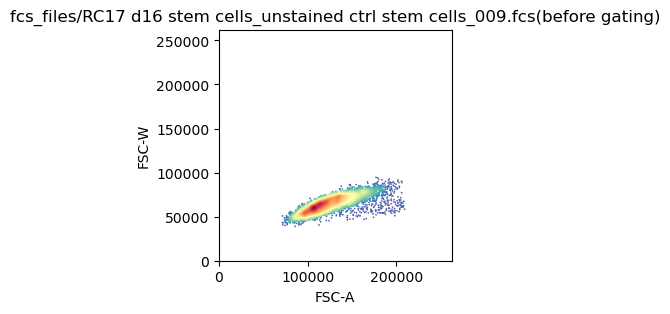

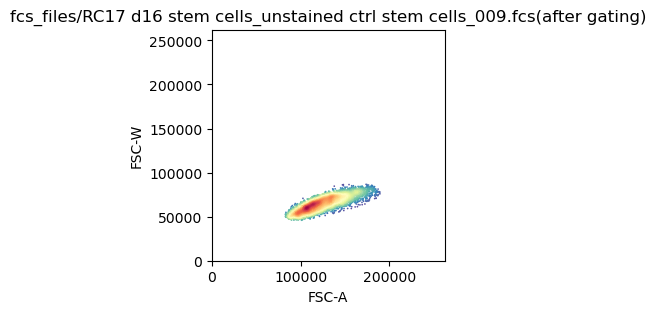

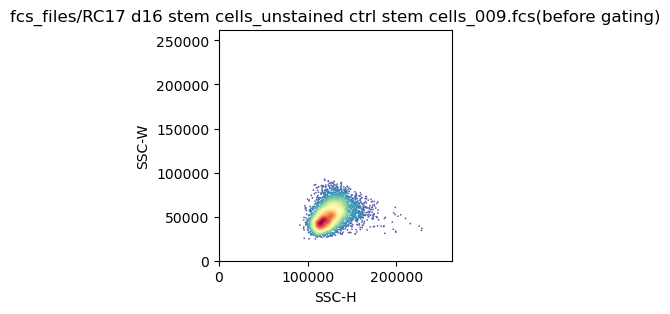

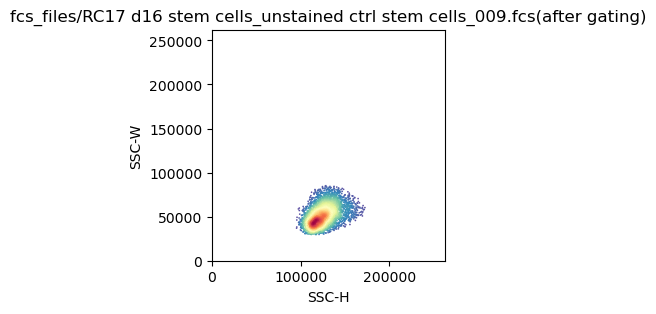

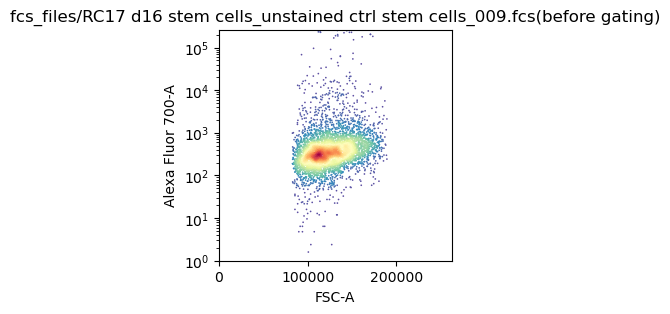

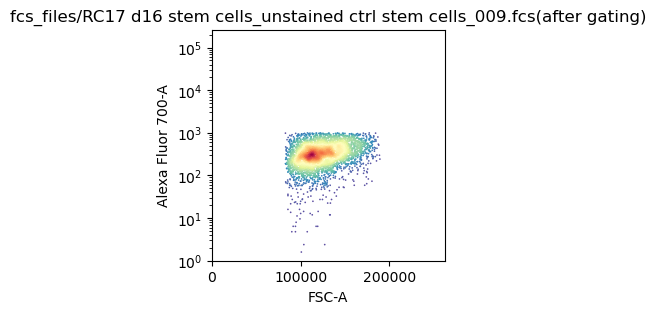

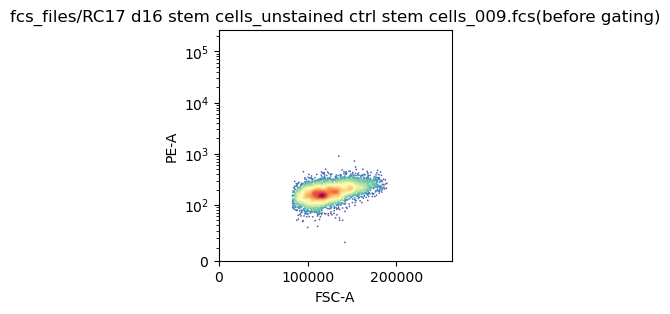

Cutoff key for PE-A: PE, Cutoff value: 503.36034820556733


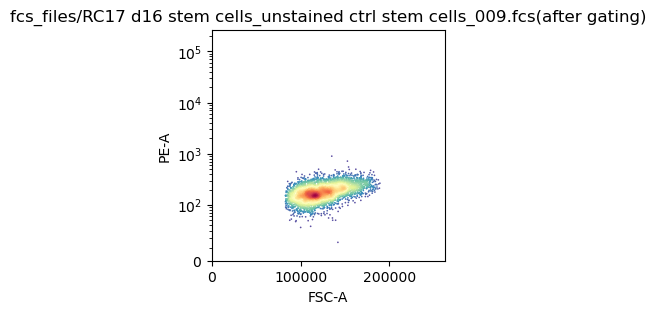

Applying gate on PE-A with cutoff 503.36034820556733 (inverse=True)
Initial count: 3929, Final count after gating: 3, Percentage retained: 0.08%


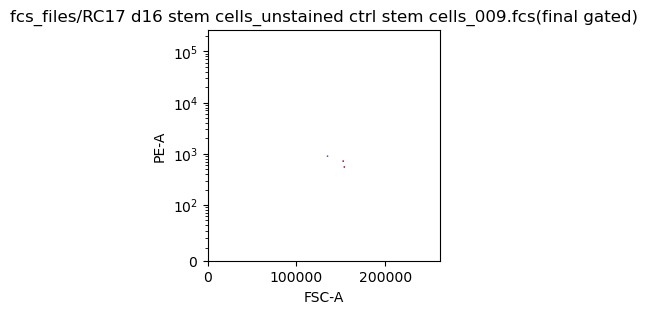

In [ ]:
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(g, channels=channels, mode=mode, xscale=xscale, yscale=yscale)
    plt.title(title)
    plt.show()

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g

#channel to cutoff mapping
channel_to_cutoff_key = {
    'PE-A': 'PE',
    'PE-Cy7-A': 'PE-Cy7',
    'Alexa Fluor 488-A': 'AF488'
}

# plot and gate the data
#count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')
    if 'stem' not in filename:
        continue
    if 'unstained' not in filename:
        continue
    #if 'IAP' not in filename:
        #continue
    #count += 1
    #if count >= 6:
        #break

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1.4e5, 1.1e5), a=35000, b=100000, theta=-40/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    #print(f"Number of live cells: {g4.shape[0]}")


    if 'FSC-A' in g4.channels and 'IAP' in filename or 'unstained ctrl PE-vio770' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'PE-Cy7-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('PE-Cy7-A')
        print(f"Cutoff key for PE-Cy7-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_pe_cy7 = plot_and_gate(g4, ['FSC-A', 'PE-Cy7-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        #use g5_pe_cy7 for further processing or plotting
        plot_and_gate(g5_pe_cy7, ['FSC-A', 'PE-Cy7-A'], filename + '(final gated)', yscale='logicle')

    elif 'APCDD1' in filename or 'TPBG' in filename or 'CORIN' in filename or 'ALCAM' in filename or 'CNTN2' in filename or 'FOLR1' in filename or '009' in filename or 'CF568' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('PE-A')
        print(f"Cutoff key for PE-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_pe = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        #use g5_pe for further processing or plotting
        plot_and_gate(g5_pe, ['FSC-A', 'PE-A'], filename + '(final gated)', yscale='logicle')
    elif 'FSC-A' in g4.channels and 'LRTM1' in filename or 'unstained ctrl AF488' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('Alexa Fluor 488-A')
        print(f"Cutoff key for Alexa Fluor 488-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_af488 = plot_and_gate(g4, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        # use g5_af488 for further processing or plotting
        plot_and_gate(g5_af488, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(final gated)', yscale='logicle')
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

In [ ]:
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(g, channels=channels, mode=mode, xscale=xscale, yscale=yscale)
    plt.title(title)
    plt.show()

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")
        # Avoid infinite recursion by not calling plot_and_gate again
        # plot_and_gate(g, channels, title.replace('before', 'after'), mode, xscale, yscale)
        #plt.figure(figsize=(4, 4))
        #FlowCal.plot.hist1d(g, channel=[channels[1]])
        #plt.title(title.replace('before', 'after'))
        #plt.show()

    return g

# Channel to cutoff key mapping
channel_to_cutoff_key = {
    'PE-A': 'PE',
    'PE-Cy7-A': 'PE-Cy7',
    'Alexa Fluor 488-A': 'AF488'
}

# plot and gate the data
#count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')
    if 'stem' not in filename:
        continue
    #if 'IAP' not in filename:
        #continue
    #count += 1
    #if count >= 6:
        #break

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 6e4), a=35000, b=100000, theta=-40/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    #print(f"Number of live cells: {g4.shape[0]}")


    if 'FSC-A' in g4.channels and 'IAP' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'PE-Cy7-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('PE-Cy7-A')
        print(f"Cutoff key for PE-Cy7-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_pe_cy7 = plot_and_gate(g4, ['FSC-A', 'PE-Cy7-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        # Use g5_pe_cy7 for further processing or plotting
        plot_and_gate(g5_pe_cy7, ['FSC-A', 'PE-Cy7-A'], filename + '(final gated)', yscale='logicle')
    elif 'APCDD1' in filename or 'TPBG' in filename or 'CORIN' in filename or 'ALCAM' in filename or 'CNTN2' in filename or 'FOLR1' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('PE-A')
        print(f"Cutoff key for PE-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_pe = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        # Use g5_pe for further processing or plotting
        plot_and_gate(g5_pe, ['FSC-A', 'PE-A'], filename + '(final gated)', yscale='logicle')
    elif 'FSC-A' in g4.channels and 'LRTM1' in filename:
        g4 = plot_and_gate(g4, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(before gating)', yscale='logicle', gate=True)
        cutoff_key = channel_to_cutoff_key.get('Alexa Fluor 488-A')
        print(f"Cutoff key for Alexa Fluor 488-A: {cutoff_key}, Cutoff value: {perc_cutoffs.get(cutoff_key)}")
        g5_af488 = plot_and_gate(g4, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs[cutoff_key], inverse=True)
        # Use g5_af488 for further processing or plotting
        plot_and_gate(g5_af488, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(final gated)', yscale='logicle')
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

## Process files (for fluo. intensity hist)

In [ ]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g


def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        channel_data = g[:, g.channels.index(channel)]
        hist, bins = np.histogram(channel_data, bins=50)
        baseline = min(hist)
        y_change = delta_y * i - baseline
        hist = hist + y_change
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

channel_to_cutoff_key = {
    'PE-A': 'PE',
    'PE-Cy7-A': 'PE-Cy7',
    'Alexa Fluor 488-A': 'AF488'
}

g4_data = []

# plot and gate the data
for i, (filename, file) in enumerate(imported_files.items()):
    if 'stem' not in filename:
        continue
    print(f'Processing... {filename}')

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1e5, 6e4), a=35000, b=100000, theta=-40/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')

    #process fluorophores separately
    #pe-cy7
    if 'FSC-A' in g4.channels and 'IAP' in filename:
        g4_data.append((filename, 'PE-Cy7-A', g4[:, g4.channels.index('PE-Cy7-A')]))
    
    #pe
    elif 'APCDD1' in filename or 'TPBG' in filename or 'CORIN' in filename or 'ALCAM' in filename or 'CNTN2' in filename or 'FOLR1' in filename:
        g4_data.append((filename, 'PE-A', g4[:, g4.channels.index('PE-A')]))
    
    #af488
    elif 'FSC-A' in g4.channels and 'LRTM1' in filename:
        g4_data.append((filename, 'Alexa Fluor 488-A', g4[:, g4.channels.index('Alexa Fluor 488-A')]))
    
    #pe for stem cells (example fmo)
    elif 'FSC-A' in g4.channels and 'unstained ctrl stem cells_009' in filename:
        g4_data.append((filename, 'PE-A', g4[:, g4.channels.index('PE-A')]))
    
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

#convert to df
df = pd.DataFrame(g4_data, columns=['Filename', 'Channel', 'Data'])

#expand Data column to separate rows
df = df.explode('Data')

#save df
df.to_csv('output/regional spec stem cells.csv', index=False)

Processing... fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 stem cells_004.fcs
Processing... fcs_files/RC17 d16 stem cells_APCDD1 1,3a,100 stem cells_005.fcs
Processing... fcs_files/RC17 d16 stem cells_CNTN2 1,3a,20 stem cells_001.fcs
Processing... fcs_files/RC17 d16 stem cells_CORIN 1,3a,200 stem cells_003.fcs
Processing... fcs_files/RC17 d16 stem cells_FOLR1 CF568 1,3a,200 stem cells_006.fcs
Processing... fcs_files/RC17 d16 stem cells_IAP 1,3a,50 stem cells_007.fcs
Processing... fcs_files/RC17 d16 stem cells_LRTM1 1,3a,20 stem cells_002.fcs
Processing... fcs_files/RC17 d16 stem cells_TPBG 1,3a,50 stem cells_008.fcs
Processing... fcs_files/RC17 d16 stem cells_unstained ctrl AF488 stem cells_010.fcs
Skipping fcs_files/RC17 d16 stem cells_unstained ctrl AF488 stem cells_010.fcs as it does not contain the relevant markers.
Processing... fcs_files/RC17 d16 stem cells_unstained ctrl CF568 stem cells_012.fcs
Skipping fcs_files/RC17 d16 stem cells_unstained ctrl CF568 stem cells_012.fcs as it

In [10]:
regional_spec_stem_cells = pd.read_csv('output/regional spec stem cells.csv')
regional_spec_stem_cells['Filename'].unique()
regional_spec_stem_cells.head()

,Filename,Channel,Data
0,"fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 s...",PE-A,2048.20
1,"fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 s...",PE-A,1581.75
2,"fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 s...",PE-A,1582.70
3,"fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 s...",PE-A,5051.15
4,"fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 s...",PE-A,2108.05


## Process files (for summarized data)

In [ ]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g


def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        # Extract the data for the specified channel
        channel_data = g[:, g.channels.index(channel)]
        # Compute the histogram
        hist, bins = np.histogram(channel_data, bins=50)
        # Compute the baseline and the y-change
        baseline = min(hist)
        y_change = delta_y * i - baseline
        # Apply the y-change to the histogram
        hist = hist + y_change
        # Plot the histogram
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


data = []

#plot and gate
for i, (filename, file) in enumerate(imported_files.items()):
    #if 'stem' not in filename:
        #continue
    print(f'Processing... {filename}')

    #gate and plot the data
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], center=(1.4e5, 1.1e5), a=35000, b=100000, theta=-40/180.*np.pi)
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.92)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.96)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1000)
    live_gate_events = g4.shape[0]


    channels_A = ['PE-A', 'PE-Cy7-A', 'Alexa Fluor 488-A']
    channels = ['PE-A', 'PE-Cy7-A', 'Alexa Fluor 488-A']
    pe_abs = ['APCDD1', 'TPBG', 'CORIN', 'ALCAM', 'CNTN2', 'FOLR1', 'unstained ctrl CF568', 'unstained ctrl stem cells_009']

        
    if 'IAP' in filename or 'unstained ctrl PE-vio770' in filename:
        channel_A = 'PE-Cy7-A'
        channel = 'PE-Cy7'
        print(channel)
    elif 'LRTM1' in filename or 'unstained ctrl AF488' in filename:
        channel_A = 'Alexa Fluor 488-A'
        channel = 'AF488'
        print(channel)
    elif any(abs in filename for abs in pe_abs):
        channel_A = 'PE-A'
        channel = 'PE'
        print(channel)
    else:
        print(f"Unknown marker in {filename}, skipping...")
        continue  # skip file if no matching marker

    #3sd
    g5 = FlowCal.gate.high_low(g4, channels=channel_A, low=perc_cutoffs[channel])
    g5_3sd = FlowCal.gate.high_low(g4, channels=channel_A, low=std_cutoffs_3[channel])
    means_3sd = np.mean(g5_3sd[:, channel_A])
    g5_gate_events = g5.shape[0]
    g5_3sd_gate_events = g5_3sd.shape[0]

    #8sd
    g5_8sd = FlowCal.gate.high_low(g4, channels=channel_A, low=std_cutoffs_8[channel])
    means_8sd = np.mean(g5_8sd[:, channel_A])
    g5_8sd_gate_events = g5_8sd.shape[0]

    #append
    data.append({
        'filename': filename,
        'live_cells_gate_events': live_gate_events,
        'percentile_gate_events': g5_gate_events,
        '3sd_gate_events': g5_3sd_gate_events,
        '3sd_mfi': means_3sd,
        '8sd_gate_events': g5_8sd_gate_events,
        '8sd_mfi': means_8sd
    })

#convert to df
df = pd.DataFrame(data)
df.to_csv('output/regional spec stem cells all markers summarized.csv', index=False)
df.head()

Processing... fcs_files/RC17 d16 rVM_ALCAM 1,3a,100 rVM_016.fcs
PE
Processing... fcs_files/RC17 d16 rVM_APCDD1 1,3a,100 rVM_017.fcs
PE
Processing... fcs_files/RC17 d16 rVM_CNTN2 1,3a,20 rVM_013.fcs
PE
Processing... fcs_files/RC17 d16 rVM_CORIN 1,3a,200 rVM_015.fcs


/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3462: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/py_flow_env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


PE
Processing... fcs_files/RC17 d16 rVM_FOLR1 CF568 1,3a,200 rVM_018.fcs
PE
Processing... fcs_files/RC17 d16 rVM_IAP 1,3a,50 rVM_019.fcs
PE-Cy7
Processing... fcs_files/RC17 d16 rVM_LRTM1 1,3a,20 rVM_014.fcs
AF488
Processing... fcs_files/RC17 d16 rVM_TPBG 1,3a,50 rVM_020.fcs
PE
Processing... fcs_files/RC17 d16 rVM_unstained ctrl AF488 rVM_022.fcs
AF488
Processing... fcs_files/RC17 d16 rVM_unstained ctrl CF568 rVM_024.fcs
PE
Processing... fcs_files/RC17 d16 rVM_unstained ctrl PE-vio770 rVM_023.fcs
PE-Cy7
Processing... fcs_files/RC17 d16 rVM_unstained ctrl rVM_021.fcs
Unknown marker in fcs_files/RC17 d16 rVM_unstained ctrl rVM_021.fcs, skipping...
Processing... fcs_files/RC17 d16 stem cells_ALCAM 1,3a,100 stem cells_004.fcs
PE
Processing... fcs_files/RC17 d16 stem cells_APCDD1 1,3a,100 stem cells_005.fcs
PE
Processing... fcs_files/RC17 d16 stem cells_CNTN2 1,3a,20 stem cells_001.fcs
PE
Processing... fcs_files/RC17 d16 stem cells_CORIN 1,3a,200 stem cells_003.fcs
PE
Processing... fcs_files

,filename,live_cells_gate_events,percentile_gate_events,3sd_gate_events,3sd_mfi,8sd_gate_events,8sd_mfi
0,"fcs_files/RC17 d16 rVM_ALCAM 1,3a,100 rVM_016.fcs",1666,1153,1292,1334.120605,852,1725.062744
1,"fcs_files/RC17 d16 rVM_APCDD1 1,3a,100 rVM_017...",1656,989,1169,907.140320,648,1184.578125
2,"fcs_files/RC17 d16 rVM_CNTN2 1,3a,20 rVM_013.fcs",1310,5,15,482.536652,0,NaN
3,"fcs_files/RC17 d16 rVM_CORIN 1,3a,200 rVM_015.fcs",1544,352,428,1022.874756,228,1437.316650
4,"fcs_files/RC17 d16 rVM_FOLR1 CF568 1,3a,200 rV...",1794,30,39,1933.590942,23,2921.952393


In [14]:
df=pd.read_csv('output/regional spec stem cells all markers summarized.csv')


region_strings = ['stem cells', 'rVM']
df['region'] = df['filename'].apply(lambda x: next((region for region in region_strings if region in x), 'unknown'))
df = df[df['region'] != 'rVM'] #filter out rows with region==rVM in the region column


#remove the string 'fcs_files/RC17 d16 ' from the filename
df['filename'] = df['filename'].str.replace('fcs_files/RC17 d16 stem cells_', '')

#extract the antibody name from the filename
ab_strings = ['APCDD1', 'TPBG', 'CORIN', 'ALCAM', 'CNTN2', 'IAP', 'LRTM1', 'FOLR1', 
              'unstained ctrl PE-vio770', 'unstained ctrl CF568', 'unstained ctrl']
df['antibody'] = df['filename'].apply(lambda x: next((ab for ab in ab_strings if ab in x), 'unknown'))

#extract the fluorophore from the antibody name
pe_abs = ['APCDD1', 'TPBG', 'CORIN', 'ALCAM', 'CNTN2', 'FOLR1', 'unstained ctrl CF568', 'unstained ctrl']

def get_fluorophore(antibody):
    if 'IAP' in antibody or 'unstained ctrl PE-vio770' in antibody:
        return 'pe_vio770'
    elif 'LRTM1' in antibody:
        return 'af488'
    elif any(abs in antibody for abs in pe_abs):
        return 'pe'
    else:
        return 'unknown'

df['fluo'] = df['antibody'].apply(get_fluorophore)

#calculate the percentage of gated events per live cells
per_pos_cols = ['percentile_gate_events', '3sd_gate_events', '8sd_gate_events']

for col in per_pos_cols:
    df[f'{col}_per_pos'] = round(100 * (df[col] / df['live_cells_gate_events']), 2)

#drop live_cells_gate_events, percentile_gate_events and 3sd_gate_events cols
df.drop(columns=['live_cells_gate_events', 'percentile_gate_events', '3sd_gate_events', '8sd_gate_events', 'region', 'filename'], inplace=True)

#remove the string '_gate_events' from the column names
df.columns = df.columns.str.replace('_gate_events', '')

#reorder the columns
df = df[['antibody', 'fluo', 'percentile_per_pos', '3sd_per_pos', '8sd_per_pos', '3sd_mfi', '8sd_mfi']]
df.head(25)

,antibody,fluo,percentile_per_pos,3sd_per_pos,8sd_per_pos,3sd_mfi,8sd_mfi
11,ALCAM,pe,99.48,99.76,97.47,2437.05760,2479.5740
12,APCDD1,pe,0.39,1.80,0.08,485.08466,927.2000
13,CNTN2,pe,97.02,98.51,91.77,3290.98140,3489.2417
14,CORIN,pe,7.63,19.39,1.48,640.06800,2422.1738
15,FOLR1,pe,27.63,40.74,12.11,846.12805,1585.5381
16,IAP,pe_vio770,97.05,99.47,79.95,1961.61630,2154.3223
17,LRTM1,af488,3.88,6.61,2.19,2225.16100,5803.2370
18,TPBG,pe,1.21,3.85,0.44,702.17630,2543.2327
19,unstained ctrl,pe,0.12,0.85,0.07,448.16772,983.2568
20,unstained ctrl CF568,pe,0.13,0.75,0.02,468.16410,768.5500
